In [3]:
# ============================================================
# STEP 1: PREPROCESSING PIPELINE
# Original + Shifted Patch Dataset Creation
# ============================================================

import os
import h5py
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

DATA_PATH = r"C:\Users\asola\Downloads\el-hackathon-2025\elucidata_ai_challenge_data.h5"

CELL_COLS = [f"C{i}" for i in range(1, 36)]

PATCH_SIZE = 128

# Manual coordinate shifts: x_used = x + dx, y_used = y + dy
SLIDE_SHIFTS = {
    "S_1": (-60, -60),
    "S_2": (-80, -80),
    "S_3": (-20, -10),
    "S_6": (-60, -20),
    # S_4 and S_5 remain unshifted unless you add them
}

def normalize_patch(patch):
    patch = patch.astype(np.float32)
    if patch.max() <= 1.0:
        return patch
    return patch / 255.0


def extract_patch_fixed(img, x, y, patch_size=128):
    """
    Extract fixed patch centered at x,y.
    Uses reflection padding for edge patches.
    """
    x, y = int(round(x)), int(round(y))
    r = patch_size // 2

    padded = cv2.copyMakeBorder(
        img,
        top=r,
        bottom=r,
        left=r,
        right=r,
        borderType=cv2.BORDER_REFLECT
    )

    x_pad = x + r
    y_pad = y + r

    patch = padded[y_pad-r:y_pad+r, x_pad-r:x_pad+r]
    return normalize_patch(patch)


def tissue_score(patch):
    """
    Rough tissue-content score.
    Higher = more texture / tissue-like content.
    """
    patch_u8 = (np.clip(patch, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(patch_u8, cv2.COLOR_RGB2GRAY)
    return gray.std() / 255.0


def inspect_h5():
    with h5py.File(DATA_PATH, "r") as f:
        print("Top-level keys:", list(f.keys()))
        print("Train images:", list(f["images/Train"].keys()))
        print("Test images:", list(f["images/Test"].keys()))
        print("Train spots:", list(f["spots/Train"].keys()))
        print("Test spots:", list(f["spots/Test"].keys()))

        img = f["images/Train/S_1"][:]
        print("\nExample image dtype:", img.dtype)
        print("Example image min/max/mean:", img.min(), img.max(), img.mean())


inspect_h5()

Top-level keys: ['images', 'spots']
Train images: ['S_1', 'S_2', 'S_3', 'S_4', 'S_5', 'S_6']
Test images: ['S_7']
Train spots: ['S_1', 'S_2', 'S_3', 'S_4', 'S_5', 'S_6']
Test spots: ['S_7']

Example image dtype: float32
Example image min/max/mean: 0.015686275 1.0 0.8712165


In [4]:
# ============================================================
# BUILD DATASET FUNCTION
# ============================================================

def build_patch_dataset(output_dir, use_shift=False):
    os.makedirs(output_dir, exist_ok=True)

    patch_root = os.path.join(output_dir, "patches")
    os.makedirs(patch_root, exist_ok=True)

    train_records = []
    test_records = []

    with h5py.File(DATA_PATH, "r") as f:

        # ----------------------------
        # TRAIN SET
        # ----------------------------
        for slide in sorted(f["spots/Train"].keys()):
            print(f"\nProcessing TRAIN {slide} | shifted={use_shift}")

            img = f[f"images/Train/{slide}"][:]
            spots = pd.DataFrame(f[f"spots/Train/{slide}"][:])

            dx, dy = SLIDE_SHIFTS.get(slide, (0, 0)) if use_shift else (0, 0)

            slide_patch_dir = os.path.join(patch_root, "train", slide)
            os.makedirs(slide_patch_dir, exist_ok=True)

            for idx, row in tqdm(spots.iterrows(), total=len(spots)):
                x_original = float(row["x"])
                y_original = float(row["y"])

                x_used = x_original + dx
                y_used = y_original + dy

                patch = extract_patch_fixed(img, x_used, y_used, PATCH_SIZE)

                patch_path = os.path.join(slide_patch_dir, f"{slide}_{idx}.npy")
                np.save(patch_path, patch)

                record = {
                    "patch_path": patch_path,
                    "slide": slide,
                    "spot_index": idx,
                    "x_original": x_original,
                    "y_original": y_original,
                    "x_used": x_used,
                    "y_used": y_used,
                    "dx": dx,
                    "dy": dy,
                    "tissue_score": tissue_score(patch),
                    "target_sum": row[CELL_COLS].sum(),
                }

                for c in CELL_COLS:
                    record[c] = row[c]

                train_records.append(record)

        # ----------------------------
        # TEST SET
        # ----------------------------
        print(f"\nProcessing TEST S_7 | shifted={use_shift}")

        img = f["images/Test/S_7"][:]
        spots = pd.DataFrame(f["spots/Test/S_7"][:])

        # Keep test unshifted for now.
        dx, dy = (0, 0)

        slide_patch_dir = os.path.join(patch_root, "test", "S_7")
        os.makedirs(slide_patch_dir, exist_ok=True)

        for idx, row in tqdm(spots.iterrows(), total=len(spots)):
            x_original = float(row["x"])
            y_original = float(row["y"])

            x_used = x_original + dx
            y_used = y_original + dy

            patch = extract_patch_fixed(img, x_used, y_used, PATCH_SIZE)

            patch_path = os.path.join(slide_patch_dir, f"S_7_{idx}.npy")
            np.save(patch_path, patch)

            record = {
                "patch_path": patch_path,
                "slide": "S_7",
                "spot_index": idx,
                "x_original": x_original,
                "y_original": y_original,
                "x_used": x_used,
                "y_used": y_used,
                "dx": dx,
                "dy": dy,
                "tissue_score": tissue_score(patch),
                "ID": row["ID"] if "ID" in spots.columns else idx,
            }

            if "Test_Set" in spots.columns:
                record["Test_Set"] = row["Test_Set"]

            test_records.append(record)

    train_meta = pd.DataFrame(train_records)
    test_meta = pd.DataFrame(test_records)

    train_meta_path = os.path.join(output_dir, "train_metadata.csv")
    test_meta_path = os.path.join(output_dir, "test_metadata.csv")

    train_meta.to_csv(train_meta_path, index=False)
    test_meta.to_csv(test_meta_path, index=False)

    print("\nSaved:")
    print(train_meta_path)
    print(test_meta_path)

    print("\nTrain shape:", train_meta.shape)
    print("Test shape:", test_meta.shape)

    return train_meta, test_meta


train_original, test_original = build_patch_dataset(
    output_dir="processed_data_original",
    use_shift=False
)

train_shifted, test_shifted = build_patch_dataset(
    output_dir="processed_data_shifted",
    use_shift=True
)


Processing TRAIN S_1 | shifted=False


100%|██████████| 2197/2197 [00:45<00:00, 48.18it/s]



Processing TRAIN S_2 | shifted=False


100%|██████████| 2270/2270 [00:54<00:00, 41.63it/s]



Processing TRAIN S_3 | shifted=False


...


Processing TRAIN S_6 | shifted=True


100%|██████████| 328/328 [00:07<00:00, 45.52it/s]



Processing TEST S_7 | shifted=True


100%|██████████| 2088/2088 [00:44<00:00, 46.90it/s]



Saved:
processed_data_shifted\train_metadata.csv
processed_data_shifted\test_metadata.csv

Train shape: (8349, 46)
Test shape: (2088, 12)


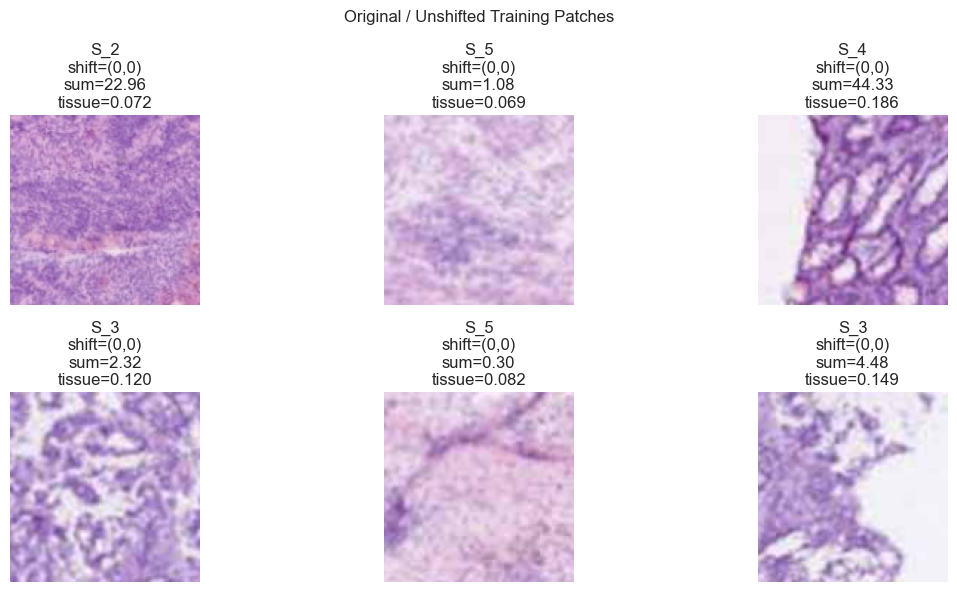

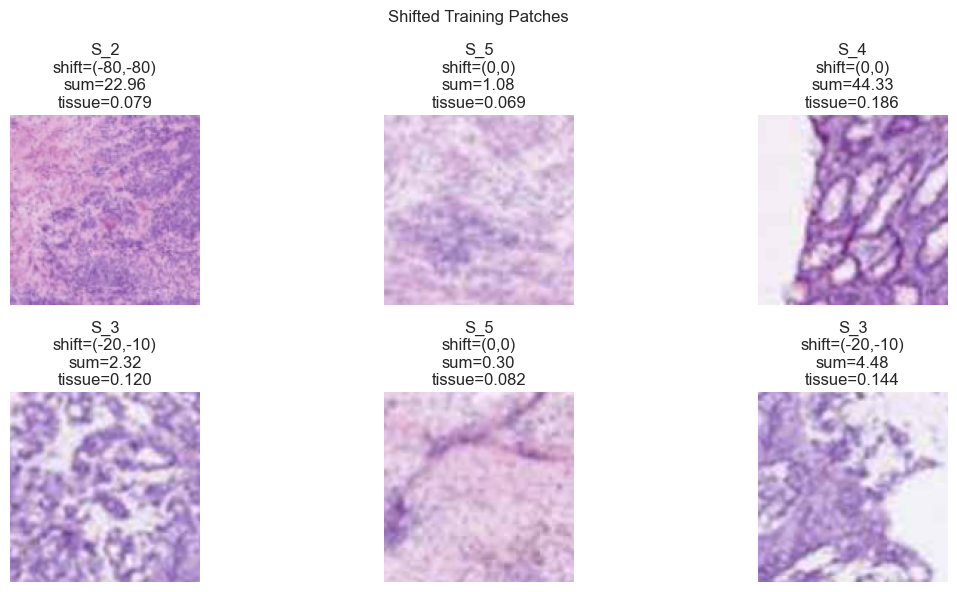

Original train slides:
slide
S_1    2197
S_2    2270
S_3     690
S_4    1187
S_5    1677
S_6     328
Name: count, dtype: int64

Shifted train slides:
slide
S_1    2197
S_2    2270
S_3     690
S_4    1187
S_5    1677
S_6     328
Name: count, dtype: int64

Original test shape: (2088, 12)
Shifted test shape: (2088, 12)


In [5]:
# ============================================================
# SANITY CHECK VISUALIZATION
# ============================================================

def show_random_patches(meta, title, n=6):
    sample = meta.sample(n, random_state=42)

    plt.figure(figsize=(12, 6))

    for i, (_, row) in enumerate(sample.iterrows()):
        patch = np.load(row["patch_path"])

        plt.subplot(2, 3, i + 1)
        plt.imshow(np.clip(patch, 0, 1))
        plt.title(
            f"{row['slide']}\n"
            f"shift=({row['dx']},{row['dy']})\n"
            f"sum={row.get('target_sum', 0):.2f}\n"
            f"tissue={row['tissue_score']:.3f}"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_random_patches(train_original, "Original / Unshifted Training Patches")
show_random_patches(train_shifted, "Shifted Training Patches")

print("Original train slides:")
print(train_original["slide"].value_counts().sort_index())

print("\nShifted train slides:")
print(train_shifted["slide"].value_counts().sort_index())

print("\nOriginal test shape:", test_original.shape)
print("Shifted test shape:", test_shifted.shape)

In [6]:
# ============================================================
# STEP 2: DATASET + DATALOADERS + VALIDATION SETUP
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

CELL_COLS = [f"C{i}" for i in range(1, 36)]

ORIGINAL_DIR = "processed_data_original"
SHIFTED_DIR = "processed_data_shifted"

BATCH_SIZE = 32
NUM_WORKERS = 0   # keep 0 on Windows/Jupyter to avoid multiprocessing issues

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# LOAD METADATA
# ============================================================

train_original = pd.read_csv(os.path.join(ORIGINAL_DIR, "train_metadata.csv"))
test_original  = pd.read_csv(os.path.join(ORIGINAL_DIR, "test_metadata.csv"))

train_shifted = pd.read_csv(os.path.join(SHIFTED_DIR, "train_metadata.csv"))
test_shifted  = pd.read_csv(os.path.join(SHIFTED_DIR, "test_metadata.csv"))

print("Original train:", train_original.shape)
print("Original test:", test_original.shape)
print("Shifted train:", train_shifted.shape)
print("Shifted test:", test_shifted.shape)

print("\nSlides:")
print(train_original["slide"].value_counts().sort_index())

Using device: cpu
Original train: (8349, 46)
Original test: (2088, 12)
Shifted train: (8349, 46)
Shifted test: (2088, 12)

Slides:
slide
S_1    2197
S_2    2270
S_3     690
S_4    1187
S_5    1677
S_6     328
Name: count, dtype: int64


In [7]:
# ============================================================
# STEP 2: DATASET + DATALOADERS + VALIDATION SETUP
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

CELL_COLS = [f"C{i}" for i in range(1, 36)]

ORIGINAL_DIR = "processed_data_original"
SHIFTED_DIR = "processed_data_shifted"

BATCH_SIZE = 32
NUM_WORKERS = 0   # keep 0 on Windows/Jupyter to avoid multiprocessing issues

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# LOAD METADATA
# ============================================================

train_original = pd.read_csv(os.path.join(ORIGINAL_DIR, "train_metadata.csv"))
test_original  = pd.read_csv(os.path.join(ORIGINAL_DIR, "test_metadata.csv"))

train_shifted = pd.read_csv(os.path.join(SHIFTED_DIR, "train_metadata.csv"))
test_shifted  = pd.read_csv(os.path.join(SHIFTED_DIR, "test_metadata.csv"))

print("Original train:", train_original.shape)
print("Original test:", test_original.shape)
print("Shifted train:", train_shifted.shape)
print("Shifted test:", test_shifted.shape)

print("\nSlides:")
print(train_original["slide"].value_counts().sort_index())

Using device: cpu
Original train: (8349, 46)
Original test: (2088, 12)
Shifted train: (8349, 46)
Shifted test: (2088, 12)

Slides:
slide
S_1    2197
S_2    2270
S_3     690
S_4    1187
S_5    1677
S_6     328
Name: count, dtype: int64


In [8]:
# ============================================================
# PYTORCH DATASET
# ============================================================

class HistologyPatchDataset(Dataset):
    def __init__(self, metadata, cell_cols=None, is_train=True):
        self.metadata = metadata.reset_index(drop=True)
        self.cell_cols = cell_cols
        self.is_train = is_train

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]

        patch = np.load(row["patch_path"])   # shape: H, W, 3, values [0,1]
        patch = torch.tensor(patch, dtype=torch.float32)

        # convert HWC -> CHW for PyTorch CNN
        patch = patch.permute(2, 0, 1)

        # optional extra numeric features
        coord_feats = torch.tensor([
            row["x_used"],
            row["y_used"],
            row["tissue_score"]
        ], dtype=torch.float32)

        if self.is_train:
            y = torch.tensor(row[self.cell_cols].values.astype(np.float32))
            return patch, coord_feats, y

        else:
            return patch, coord_feats, row["ID"]

In [9]:
# ============================================================
# SLIDE-WISE TRAIN / VALIDATION SPLIT
# ============================================================
# We validate on one full slide to mimic test-slide generalization.
# Start with S_6 as validation, like many baseline notebooks.

VAL_SLIDE = "S_6"

def make_slide_split(meta, val_slide="S_6"):
    train_meta = meta[meta["slide"] != val_slide].reset_index(drop=True)
    val_meta   = meta[meta["slide"] == val_slide].reset_index(drop=True)
    return train_meta, val_meta


orig_train_meta, orig_val_meta = make_slide_split(train_original, VAL_SLIDE)
shift_train_meta, shift_val_meta = make_slide_split(train_shifted, VAL_SLIDE)

print("Original split:")
print("Train:", orig_train_meta.shape)
print("Val:", orig_val_meta.shape)

print("\nShifted split:")
print("Train:", shift_train_meta.shape)
print("Val:", shift_val_meta.shape)

Original split:
Train: (8021, 46)
Val: (328, 46)

Shifted split:
Train: (8021, 46)
Val: (328, 46)


In [10]:
# ============================================================
# CREATE DATALOADERS
# ============================================================

def make_loaders(train_meta, val_meta, batch_size=32):
    train_ds = HistologyPatchDataset(
        metadata=train_meta,
        cell_cols=CELL_COLS,
        is_train=True
    )

    val_ds = HistologyPatchDataset(
        metadata=val_meta,
        cell_cols=CELL_COLS,
        is_train=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    return train_loader, val_loader


orig_train_loader, orig_val_loader = make_loaders(
    orig_train_meta,
    orig_val_meta,
    BATCH_SIZE
)

shift_train_loader, shift_val_loader = make_loaders(
    shift_train_meta,
    shift_val_meta,
    BATCH_SIZE
)

# Test one batch
patches, coord_feats, y = next(iter(orig_train_loader))

print("Patch batch:", patches.shape)
print("Coord batch:", coord_feats.shape)
print("Target batch:", y.shape)

Patch batch: torch.Size([32, 3, 128, 128])
Coord batch: torch.Size([32, 3])
Target batch: torch.Size([32, 35])


In [11]:
# ============================================================
# METRIC: MEAN SPOT-WISE SPEARMAN
# ============================================================

def mean_spot_spearman(y_true, y_pred):
    """
    Competition-like metric:
    Spearman correlation across 35 cell types per spot,
    averaged across spots.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    scores = []

    for i in range(len(y_true)):
        corr = spearmanr(y_true[i], y_pred[i]).correlation

        if not np.isnan(corr):
            scores.append(corr)

    return float(np.mean(scores))


# quick sanity test
random_pred = np.random.rand(len(orig_val_meta), 35)
true_val = orig_val_meta[CELL_COLS].values

print("Random Spearman:", mean_spot_spearman(true_val, random_pred))

Random Spearman: -0.004380166700826669


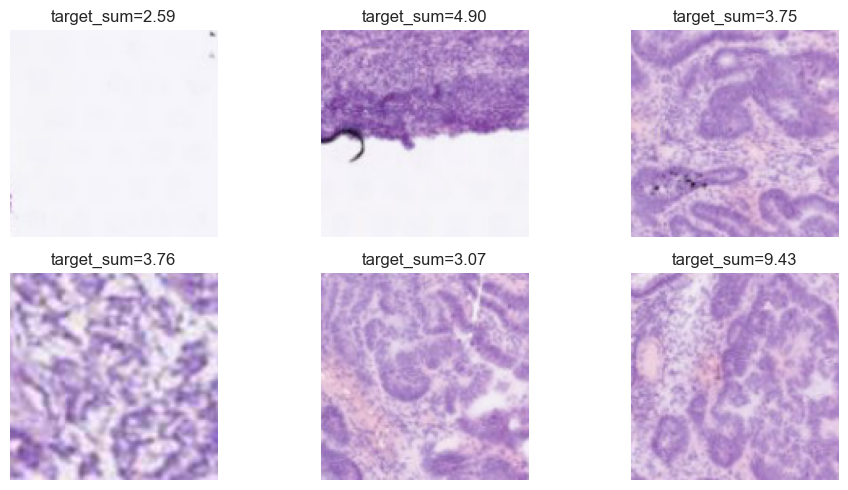

In [12]:
# ============================================================
#VISUAL CHECK FROM DATALOADER
# ============================================================

patches, coord_feats, y = next(iter(orig_train_loader))

plt.figure(figsize=(10, 5))

for i in range(6):
    img = patches[i].permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"target_sum={y[i].sum():.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# MODEL: ResNet18 + Coord Features + MLP Head
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models

class ResNet18Regressor(nn.Module):
    def __init__(self, num_outputs=35, coord_dim=3):
        super().__init__()

        # Pretrained ResNet18
        self.backbone = models.resnet18(pretrained=True)

        # Remove final FC layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Final regression head
        self.head = nn.Sequential(
            nn.Linear(in_features + coord_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_outputs)
        )

    def forward(self, x, coord_feats):
        features = self.backbone(x)              # (B, 512)
        combined = torch.cat([features, coord_feats], dim=1)
        out = self.head(combined)
        return out

In [14]:
# ============================================================
# TRAINING UTILITIES
# ============================================================

import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for patches, coords, targets in loader:
        patches = patches.to(DEVICE)
        coords = coords.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(patches, coords)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for patches, coords, targets in loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(patches, coords)

            loss = criterion(outputs, targets)
            total_loss += loss.item()

            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    spearman = mean_spot_spearman(all_targets, all_preds)

    return total_loss / len(loader), spearman

In [15]:
# ============================================================
# TRAINING LOOP (ORIGINAL DATASET)
# ============================================================

EPOCHS = 5
LR = 1e-4

model = ResNet18Regressor().to(DEVICE)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LR)

best_val_score = -1

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        orig_train_loader,
        optimizer,
        criterion
    )

    val_loss, val_spearman = validate(
        model,
        orig_val_loader,
        criterion
    )

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Spearman: {val_spearman:.4f}")

    if val_spearman > best_val_score:
        best_val_score = val_spearman
        torch.save(model.state_dict(), "best_model_original.pth")
        print("Saved best model!")

print("\nBest Val Spearman (Original):", best_val_score)

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/5
Train Loss: 1.4641
Val Loss: 0.1423
Val Spearman: 0.1891
Saved best model!

Epoch 2/5
Train Loss: 0.2749
Val Loss: 0.1261
Val Spearman: 0.3519
Saved best model!

Epoch 3/5
Train Loss: 0.2557
Val Loss: 0.1208
Val Spearman: 0.4917
Saved best model!

Epoch 4/5
Train Loss: 0.2518
Val Loss: 0.1204
Val Spearman: 0.5343
Saved best model!

Epoch 5/5
Train Loss: 0.2512
Val Loss: 0.1203
Val Spearman: 0.5628
Saved best model!

Best Val Spearman (Original): 0.5628424540547926


In [16]:
# ============================================================
# TRAINING LOOP (SHIFTED DATASET)
# ============================================================

model_shifted = ResNet18Regressor().to(DEVICE)

criterion = nn.L1Loss()
optimizer = optim.Adam(model_shifted.parameters(), lr=LR)

best_val_score_shifted = -1

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS} [SHIFTED]")

    train_loss = train_one_epoch(
        model_shifted,
        shift_train_loader,
        optimizer,
        criterion
    )

    val_loss, val_spearman = validate(
        model_shifted,
        shift_val_loader,
        criterion
    )

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Spearman: {val_spearman:.4f}")

    if val_spearman > best_val_score_shifted:
        best_val_score_shifted = val_spearman
        torch.save(model_shifted.state_dict(), "best_model_shifted.pth")
        print("Saved best model!")

print("\nBest Val Spearman (Shifted):", best_val_score_shifted)

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/5 [SHIFTED]
Train Loss: 1.2564
Val Loss: 0.1382
Val Spearman: 0.0474
Saved best model!

Epoch 2/5 [SHIFTED]
Train Loss: 0.2720
Val Loss: 0.1234
Val Spearman: 0.2107
Saved best model!

Epoch 3/5 [SHIFTED]
Train Loss: 0.2552
Val Loss: 0.1180
Val Spearman: 0.4894
Saved best model!

Epoch 4/5 [SHIFTED]
Train Loss: 0.2517
Val Loss: 0.1171
Val Spearman: 0.5506
Saved best model!

Epoch 5/5 [SHIFTED]
Train Loss: 0.2502
Val Loss: 0.1169
Val Spearman: 0.5666
Saved best model!

Best Val Spearman (Shifted): 0.5666214046594248


In [17]:
# ============================================================
# LOAD BEST SHIFTED MODEL
# ============================================================

base_model = ResNet18Regressor().to(DEVICE)

checkpoint = torch.load("best_model_shifted.pth", map_location=DEVICE)

# Since you saved only state_dict:
base_model.load_state_dict(checkpoint)

base_model.eval()

print("Model loaded successfully (shifted)")

Model loaded successfully (shifted)


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
# ============================================================
# GET VALIDATION PREDICTIONS (S_6)
# ============================================================

def get_predictions(model, loader):
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for patches, coords, targets in loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)

            outputs = model(patches, coords)

            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.numpy())

    return np.concatenate(all_preds), np.concatenate(all_targets)


val_pred, val_true = get_predictions(base_model, shift_val_loader)

print("Prediction shape:", val_pred.shape)
print("Target shape:", val_true.shape)

base_score = mean_spot_spearman(val_true, val_pred)
print("\nBase S_6 Spearman:", base_score)

Prediction shape: (328, 35)
Target shape: (328, 35)

Base S_6 Spearman: 0.5666214046594248


In [19]:
# ============================================================
# RIDGE REFINEMENT (QUICK TEST)
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=1.0))
)

ridge.fit(val_pred, val_true)

val_pred_ridge = ridge.predict(val_pred)
val_pred_ridge = np.clip(val_pred_ridge, 0, None)

ridge_score = mean_spot_spearman(val_true, val_pred_ridge)

print("\nRidge-refined S_6 Spearman:", ridge_score)


Ridge-refined S_6 Spearman: 0.6825134932021589


In [20]:
# ============================================================
# ALPHA SWEEP (IMPORTANT)
# ============================================================

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

print("\nAlpha Sweep Results:")

for alpha in alphas:
    ridge = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(Ridge(alpha=alpha))
    )

    ridge.fit(val_pred, val_true)
    pred_refined = ridge.predict(val_pred)
    pred_refined = np.clip(pred_refined, 0, None)

    score = mean_spot_spearman(val_true, pred_refined)

    print(f"alpha={alpha:<6} Spearman={score:.4f}")


Alpha Sweep Results:
alpha=0.01   Spearman=0.6825
alpha=0.1    Spearman=0.6825
alpha=1.0    Spearman=0.6825
alpha=10.0   Spearman=0.6825
alpha=100.0  Spearman=0.6825


In [21]:
# ============================================================
# STEP 4B: FULL LEAVE-ONE-SLIDE-OUT CV + OOF PREDICTIONS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

CV_DIR = "cv_models_shifted"
os.makedirs(CV_DIR, exist_ok=True)

META = train_shifted.copy()
SLIDES = sorted(META["slide"].unique())

EPOCHS_CV = 5
LR = 1e-4
BATCH_SIZE = 32

oof_preds = np.zeros((len(META), 35), dtype=np.float32)
oof_true  = META[CELL_COLS].values.astype(np.float32)

fold_scores = {}

for val_slide in SLIDES:
    print("\n" + "="*70)
    print(f"FOLD: validation slide = {val_slide}")
    print("="*70)

    train_meta_fold = META[META["slide"] != val_slide].reset_index(drop=True)
    val_meta_fold   = META[META["slide"] == val_slide].reset_index(drop=True)

    train_ds = HistologyPatchDataset(
        metadata=train_meta_fold,
        cell_cols=CELL_COLS,
        is_train=True
    )

    val_ds = HistologyPatchDataset(
        metadata=val_meta_fold,
        cell_cols=CELL_COLS,
        is_train=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    model = ResNet18Regressor().to(DEVICE)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_score = -999
    best_path = os.path.join(CV_DIR, f"best_model_val_{val_slide}.pth")

    for epoch in range(EPOCHS_CV):
        print(f"\nEpoch {epoch+1}/{EPOCHS_CV} | Val slide: {val_slide}")

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_spearman = validate(
            model,
            val_loader,
            criterion
        )

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Spearman: {val_spearman:.4f}")

        if val_spearman > best_score:
            best_score = val_spearman

            torch.save(model.state_dict(), best_path)
            print(f"Saved best fold model: {best_path}")

    fold_scores[val_slide] = best_score

    # Reload best model for this fold
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()

    fold_preds = []
    fold_targets = []

    with torch.no_grad():
        for patches, coords, targets in val_loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)

            preds = model(patches, coords).cpu().numpy()

            fold_preds.append(preds)
            fold_targets.append(targets.numpy())

    fold_preds = np.concatenate(fold_preds)
    fold_targets = np.concatenate(fold_targets)

    # Put fold predictions into correct OOF rows
    original_indices = META[META["slide"] == val_slide].index.values
    oof_preds[original_indices] = fold_preds

    print(f"\nBest Spearman for {val_slide}: {best_score:.4f}")

print("\n" + "="*70)
print("CV COMPLETE")
print("="*70)

for slide, score in fold_scores.items():
    print(f"{slide}: {score:.4f}")

overall_oof_score = mean_spot_spearman(oof_true, oof_preds)
print("\nOverall OOF Spearman:", overall_oof_score)

np.save(os.path.join(CV_DIR, "oof_preds.npy"), oof_preds)
np.save(os.path.join(CV_DIR, "oof_true.npy"), oof_true)

pd.DataFrame(fold_scores.items(), columns=["slide", "spearman"]).to_csv(
    os.path.join(CV_DIR, "fold_scores.csv"),
    index=False
)

print("\nSaved OOF predictions and fold scores.")


FOLD: validation slide = S_1

Epoch 1/5 | Val slide: S_1


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 1.3249
Val Loss: 0.2999
Val Spearman: -0.0682
Saved best fold model: cv_models_shifted\best_model_val_S_1.pth

Epoch 2/5 | Val slide: S_1
Train Loss: 0.2753
Val Loss: 0.2863
Val Spearman: 0.0003
Saved best fold model: cv_models_shifted\best_model_val_S_1.pth

Epoch 3/5 | Val slide: S_1
Train Loss: 0.2505
Val Loss: 0.2805
Val Spearman: 0.0929
Saved best fold model: cv_models_shifted\best_model_val_S_1.pth

Epoch 4/5 | Val slide: S_1
Train Loss: 0.2418
Val Loss: 0.2767
Val Spearman: 0.3353
Saved best fold model: cv_models_shifted\best_model_val_S_1.pth

Epoch 5/5 | Val slide: S_1
Train Loss: 0.2378
Val Loss: 0.2756
Val Spearman: 0.3802
Saved best fold model: cv_models_shifted\best_model_val_S_1.pth

Best Spearman for S_1: 0.3802

FOLD: validation slide = S_2

Epoch 1/5 | Val slide: S_2


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 1.7866
Val Loss: 0.3647
Val Spearman: -0.0706
Saved best fold model: cv_models_shifted\best_model_val_S_2.pth

Epoch 2/5 | Val slide: S_2
Train Loss: 0.2560
Val Loss: 0.3503
Val Spearman: 0.0715
Saved best fold model: cv_models_shifted\best_model_val_S_2.pth

Epoch 3/5 | Val slide: S_2
Train Loss: 0.2216
Val Loss: 0.3443
Val Spearman: 0.3546
Saved best fold model: cv_models_shifted\best_model_val_S_2.pth

Epoch 4/5 | Val slide: S_2
Train Loss: 0.2150
Val Loss: 0.3424
Val Spearman: 0.5304
Saved best fold model: cv_models_shifted\best_model_val_S_2.pth

Epoch 5/5 | Val slide: S_2
Train Loss: 0.2123
Val Loss: 0.3418
Val Spearman: 0.5511
Saved best fold model: cv_models_shifted\best_model_val_S_2.pth

Best Spearman for S_2: 0.5511

FOLD: validation slide = S_3

Epoch 1/5 | Val slide: S_3


...

Train Loss: 1.1583
Val Loss: 0.2700
Val Spearman: 0.0383
Saved best fold model: cv_models_shifted\best_model_val_S_4.pth

Epoch 2/5 | Val slide: S_4
Train Loss: 0.2696
Val Loss: 0.2575
Val Spearman: 0.2542
Saved best fold model: cv_models_shifted\best_model_val_S_4.pth

Epoch 3/5 | Val slide: S_4
Train Loss: 0.2517
Val Loss: 0.2525
Val Spearman: 0.3759
Saved best fold model: cv_models_shifted\best_model_val_S_4.pth

Epoch 4/5 | Val slide: S_4
Train Loss: 0.2464
Val Loss: 0.2512
Val Spearman: 0.4870
Saved best fold model: cv_models_shifted\best_model_val_S_4.pth

Epoch 5/5 | Val slide: S_4
Train Loss: 0.2451
Val Loss: 0.2509
Val Spearman: 0.4942
Saved best fold model: cv_models_shifted\best_model_val_S_4.pth

Best Spearman for S_4: 0.4942

FOLD: validation slide = S_5

Epoch 1/5 | Val slide: S_5


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 1.7503
Val Loss: 0.1919
Val Spearman: 0.0730
Saved best fold model: cv_models_shifted\best_model_val_S_5.pth

Epoch 2/5 | Val slide: S_5
Train Loss: 0.3046
Val Loss: 0.1779
Val Spearman: 0.1476
Saved best fold model: cv_models_shifted\best_model_val_S_5.pth

Epoch 3/5 | Val slide: S_5
Train Loss: 0.2751
Val Loss: 0.1723
Val Spearman: 0.2256
Saved best fold model: cv_models_shifted\best_model_val_S_5.pth

Epoch 4/5 | Val slide: S_5
Train Loss: 0.2671
Val Loss: 0.1706
Val Spearman: 0.2588
Saved best fold model: cv_models_shifted\best_model_val_S_5.pth

Epoch 5/5 | Val slide: S_5
Train Loss: 0.2643
Val Loss: 0.1711
Val Spearman: 0.2825
Saved best fold model: cv_models_shifted\best_model_val_S_5.pth

Best Spearman for S_5: 0.2825

FOLD: validation slide = S_6

Epoch 1/5 | Val slide: S_6


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 1.4128
Val Loss: 0.1449
Val Spearman: -0.0176
Saved best fold model: cv_models_shifted\best_model_val_S_6.pth

Epoch 2/5 | Val slide: S_6
Train Loss: 0.2810
Val Loss: 0.1267
Val Spearman: 0.2301
Saved best fold model: cv_models_shifted\best_model_val_S_6.pth

Epoch 3/5 | Val slide: S_6
Train Loss: 0.2588
Val Loss: 0.1193
Val Spearman: 0.4611
Saved best fold model: cv_models_shifted\best_model_val_S_6.pth

Epoch 4/5 | Val slide: S_6
Train Loss: 0.2531
Val Loss: 0.1184
Val Spearman: 0.5722
Saved best fold model: cv_models_shifted\best_model_val_S_6.pth

Epoch 5/5 | Val slide: S_6
Train Loss: 0.2514
Val Loss: 0.1183
Val Spearman: 0.5618

Best Spearman for S_6: 0.5722

CV COMPLETE
S_1: 0.3802
S_2: 0.5511
S_3: 0.6628
S_4: 0.4942
S_5: 0.2825
S_6: 0.5722

Overall OOF Spearman: 0.45412875894159327

Saved OOF predictions and fold scores.


In [22]:
# ============================================================
# STEP 4C: PROPER RIDGE REFINEMENT ON OOF PREDICTIONS
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 300.0, 1000.0]

print("Base OOF Spearman:", mean_spot_spearman(oof_true, oof_preds))
print("\nRidge OOF Alpha Sweep:")

best_alpha = None
best_ridge_score = -999
best_ridge_model = None

for alpha in alphas:
    ridge = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(Ridge(alpha=alpha))
    )

    ridge.fit(oof_preds, oof_true)

    refined_oof = ridge.predict(oof_preds)
    refined_oof = np.clip(refined_oof, 0, None)

    score = mean_spot_spearman(oof_true, refined_oof)

    print(f"alpha={alpha:<8} OOF Spearman={score:.4f}")

    if score > best_ridge_score:
        best_ridge_score = score
        best_alpha = alpha
        best_ridge_model = ridge

print("\nBest Ridge alpha:", best_alpha)
print("Best Ridge OOF Spearman:", best_ridge_score)

Base OOF Spearman: 0.45412875894159327

Ridge OOF Alpha Sweep:
alpha=0.01     OOF Spearman=0.6225


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.77

alpha=0.1      OOF Spearman=0.6225
alpha=1.0      OOF Spearman=0.6225
alpha=10.0     OOF Spearman=0.6224
alpha=100.0    OOF Spearman=0.6220
alpha=300.0    OOF Spearman=0.6189
alpha=1000.0   OOF Spearman=0.6117

Best Ridge alpha: 0.01
Best Ridge OOF Spearman: 0.6224831434550105


In [23]:
# ============================================================
# SAVE EVERYTHING TO DOWNLOADS
# ============================================================

import os
import joblib
import json

SAVE_DIR = r"C:\Users\asola\Downloads"
os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# 1. Save Ridge model
# ----------------------------
ridge_path = os.path.join(SAVE_DIR, "ridge_model.joblib")
joblib.dump(best_ridge_model, ridge_path)
print("Saved Ridge model:", ridge_path)

# ----------------------------
# 2. Save OOF predictions
# ----------------------------
np.save(os.path.join(SAVE_DIR, "oof_preds.npy"), oof_preds)
np.save(os.path.join(SAVE_DIR, "oof_true.npy"), oof_true)

refined_oof = best_ridge_model.predict(oof_preds)
refined_oof = np.clip(refined_oof, 0, None)

np.save(os.path.join(SAVE_DIR, "oof_preds_refined.npy"), refined_oof)

print("Saved OOF predictions")

# ----------------------------
# 3. Save summary
# ----------------------------
summary = {
    "base_oof_spearman": float(overall_oof_score),
    "ridge_oof_spearman": float(best_ridge_score),
    "best_alpha": float(best_alpha)
}

summary_path = os.path.join(SAVE_DIR, "summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Saved summary:", summary_path)

# ----------------------------
# 4. Copy fold models to Downloads
# ----------------------------
import shutil

for file in os.listdir(CV_DIR):
    if file.endswith(".pth"):
        src = os.path.join(CV_DIR, file)
        dst = os.path.join(SAVE_DIR, file)
        shutil.copy(src, dst)

print("Copied fold models to Downloads")

# ----------------------------
# 5. Verify
# ----------------------------
print("\nFiles in Downloads:")
for f in os.listdir(SAVE_DIR):
    if "model" in f or "oof" in f or "summary" in f:
        print(" -", f)

Saved Ridge model: C:\Users\asola\Downloads\ridge_model.joblib
Saved OOF predictions
Saved summary: C:\Users\asola\Downloads\summary.json
Copied fold models to Downloads

Files in Downloads:
 - best_model_val_S_1.pth
 - best_model_val_S_2.pth
 - best_model_val_S_3.pth
 - best_model_val_S_4.pth
 - best_model_val_S_5.pth
 - best_model_val_S_6.pth
 - Fitted_resonance_model_parameters.csv
 - Hunter-Hound_SEAD_Doctrine_Proof_Ownership.txt
 - introduction-to-probability-model-s.ross-math-cs.blog_.ir_ (1).pdf
 - introduction-to-probability-model-s.ross-math-cs.blog_.ir_.pdf
 - oof_preds.npy
 - oof_preds_refined.npy
 - oof_true.npy
 - ridge_model.joblib
 - rooftop_319.zip
 - summary.json
 - vcvs_model.png


In [24]:
# ============================================================
# STEP 5: TEST PREDICTIONS ONLY
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

SAVE_DIR = r"C:\Users\asola\Downloads"
SHIFTED_DIR = "processed_data_shifted"

CELL_COLS = [f"C{i}" for i in range(1, 36)]

test_meta = pd.read_csv(os.path.join(SHIFTED_DIR, "test_metadata.csv"))

test_ds = HistologyPatchDataset(
    metadata=test_meta,
    cell_cols=CELL_COLS,
    is_train=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Test spots:", len(test_ds))

Test spots: 2088


In [25]:
# ============================================================
# PREDICT WITH ALL 6 CV MODELS
# ============================================================

fold_model_files = [
    "best_model_val_S_1.pth",
    "best_model_val_S_2.pth",
    "best_model_val_S_3.pth",
    "best_model_val_S_4.pth",
    "best_model_val_S_5.pth",
    "best_model_val_S_6.pth",
]

all_fold_preds = []

for model_file in fold_model_files:
    model_path = os.path.join(SAVE_DIR, model_file)

    model = ResNet18Regressor().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    preds_list = []

    with torch.no_grad():
        for patches, coords, ids in test_loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)

            preds = model(patches, coords).cpu().numpy()
            preds_list.append(preds)

    fold_preds = np.concatenate(preds_list, axis=0)
    all_fold_preds.append(fold_preds)

    print(f"{model_file} prediction shape:", fold_preds.shape)

base_test_preds = np.mean(all_fold_preds, axis=0)
base_test_preds = np.clip(base_test_preds, 0, None)

print("\nBase test prediction shape:", base_test_preds.shape)

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


best_model_val_S_1.pth prediction shape: (2088, 35)
best_model_val_S_2.pth prediction shape: (2088, 35)
best_model_val_S_3.pth prediction shape: (2088, 35)
best_model_val_S_4.pth prediction shape: (2088, 35)
best_model_val_S_5.pth prediction shape: (2088, 35)
best_model_val_S_6.pth prediction shape: (2088, 35)

Base test prediction shape: (2088, 35)


In [26]:
# ============================================================
# APPLY RIDGE REFINEMENT
# ============================================================

ridge_path = os.path.join(SAVE_DIR, "ridge_model.joblib")
ridge_model = joblib.load(ridge_path)

ridge_test_preds = ridge_model.predict(base_test_preds)
ridge_test_preds = np.clip(ridge_test_preds, 0, None)

print("Ridge-refined test prediction shape:", ridge_test_preds.shape)
print("Min:", ridge_test_preds.min())
print("Max:", ridge_test_preds.max())
print("Mean:", ridge_test_preds.mean())

Ridge-refined test prediction shape: (2088, 35)
Min: 0.013583313
Max: 1.4745153
Mean: 0.2142117


In [27]:
# ============================================================
# SAVE TEST PREDICTIONS ONLY
# ============================================================

base_pred_path = os.path.join(SAVE_DIR, "test_preds_base.npy")
ridge_pred_path = os.path.join(SAVE_DIR, "test_preds_ridge.npy")

np.save(base_pred_path, base_test_preds)
np.save(ridge_pred_path, ridge_test_preds)

print("Saved base test predictions:", base_pred_path)
print("Saved Ridge-refined test predictions:", ridge_pred_path)

Saved base test predictions: C:\Users\asola\Downloads\test_preds_base.npy
Saved Ridge-refined test predictions: C:\Users\asola\Downloads\test_preds_ridge.npy


In [28]:
# ============================================================
# STEP 6: IMPROVE REFINEMENT MODEL WITHOUT RETRAINING CNN
# ============================================================

import os
import numpy as np
import joblib

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor

SAVE_DIR = r"C:\Users\asola\Downloads"

oof_preds = np.load(os.path.join(SAVE_DIR, "oof_preds.npy"))
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

print("OOF preds:", oof_preds.shape)
print("OOF true:", oof_true.shape)

def evaluate_refiner(name, model):
    model.fit(oof_preds, oof_true)
    pred = model.predict(oof_preds)
    pred = np.clip(pred, 0, None)
    score = mean_spot_spearman(oof_true, pred)
    print(f"{name:<25} Spearman: {score:.5f}")
    return name, model, pred, score

OOF preds: (8349, 35)
OOF true: (8349, 35)


In [29]:
# ============================================================
# TRY MULTIPLE REFINERS
# WARNING: These are trained/evaluated on same OOF set.
# Good for comparison, but final choice should be checked carefully.
# ============================================================

results = []

# 1. Ridge variants
for alpha in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(Ridge(alpha=alpha))
    )
    results.append(evaluate_refiner(f"Ridge alpha={alpha}", model))

# 2. ElasticNet variants
for alpha in [0.0001, 0.001, 0.01]:
    model = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(
            ElasticNet(alpha=alpha, l1_ratio=0.2, max_iter=5000)
        )
    )
    results.append(evaluate_refiner(f"ElasticNet a={alpha}", model))

# 3. Tree-based refiners
model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
results.append(evaluate_refiner("ExtraTrees depth=8", model))

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
results.append(evaluate_refiner("RandomForest depth=8", model))

# 4. MLP refiner
model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
)
results.append(evaluate_refiner("MLP 128-64", model))

Ridge alpha=0.001         Spearman: 0.62248
Ridge alpha=0.01          Spearman: 0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.779615896983614e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.77

Ridge alpha=0.1           Spearman: 0.62248
Ridge alpha=1             Spearman: 0.62248
Ridge alpha=10            Spearman: 0.62239
Ridge alpha=100           Spearman: 0.62204


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.175e+04, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.436e-01, tolerance: 2.498e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

ElasticNet a=0.0001       Spearman: 0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.413e+00, tolerance: 1.168e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.670e+00, tolerance: 2.818e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

ElasticNet a=0.001        Spearman: 0.62286
ElasticNet a=0.01         Spearman: 0.62009
ExtraTrees depth=8        Spearman: 0.62248
RandomForest depth=8      Spearman: 0.62248
MLP 128-64                Spearman: 0.59114


In [30]:
# ============================================================
# SORT RESULTS
# ============================================================

results_sorted = sorted(results, key=lambda x: x[3], reverse=True)

print("\nBest refiners:")
for name, model, pred, score in results_sorted:
    print(f"{name:<25} {score:.5f}")


Best refiners:
ElasticNet a=0.001        0.62286
Ridge alpha=0.001         0.62248
Ridge alpha=0.01          0.62248
Ridge alpha=0.1           0.62248
Ridge alpha=1             0.62248
ElasticNet a=0.0001       0.62248
ExtraTrees depth=8        0.62248
RandomForest depth=8      0.62248
Ridge alpha=10            0.62239
Ridge alpha=100           0.62204
ElasticNet a=0.01         0.62009
MLP 128-64                0.59114


In [31]:
# ============================================================
# BLENDING TOP REFINERS
# ============================================================

best_name, best_model, best_pred, best_score = results_sorted[0]

# get ridge prediction separately
ridge_model = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=0.01))
)
ridge_model.fit(oof_preds, oof_true)
ridge_pred = np.clip(ridge_model.predict(oof_preds), 0, None)

print("Ridge score:", mean_spot_spearman(oof_true, ridge_pred))
print("Best model:", best_name, best_score)

for w in np.linspace(0, 1, 11):
    blended = w * ridge_pred + (1 - w) * best_pred
    score = mean_spot_spearman(oof_true, blended)
    print(f"ridge_weight={w:.1f} blend_score={score:.5f}")

Ridge score: 0.6224831434550105
Best model: ElasticNet a=0.001 0.6228615916362953
ridge_weight=0.0 blend_score=0.62286
ridge_weight=0.1 blend_score=0.62290
ridge_weight=0.2 blend_score=0.62259
ridge_weight=0.3 blend_score=0.62267
ridge_weight=0.4 blend_score=0.62267
ridge_weight=0.5 blend_score=0.62266
ridge_weight=0.6 blend_score=0.62266
ridge_weight=0.7 blend_score=0.62272
ridge_weight=0.8 blend_score=0.62272
ridge_weight=0.9 blend_score=0.62248
ridge_weight=1.0 blend_score=0.62248


In [32]:
# ============================================================
# SAVE BEST REFINER
# ============================================================

best_name, best_model, best_pred, best_score = results_sorted[0]

joblib.dump(best_model, os.path.join(SAVE_DIR, "best_refiner_model.joblib"))

summary = {
    "best_refiner_name": best_name,
    "best_refiner_score": float(best_score),
}

import json
with open(os.path.join(SAVE_DIR, "best_refiner_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("Saved best refiner:", best_name, best_score)

Saved best refiner: ElasticNet a=0.001 0.6228615916362953


In [33]:
# ============================================================
# STEP 6B: REFINER WITH COORD + TISSUE FEATURES
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib
import json

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SAVE_DIR = r"C:\Users\asola\Downloads"
SHIFTED_DIR = "processed_data_shifted"

# Load saved OOF predictions and true labels
oof_preds = np.load(os.path.join(SAVE_DIR, "oof_preds.npy"))
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

# Load metadata in the same order used for CV
meta = pd.read_csv(os.path.join(SHIFTED_DIR, "train_metadata.csv"))

extra_feats = meta[["x_used", "y_used", "tissue_score"]].values.astype(np.float32)

# Optional: normalize x,y roughly by image-scale-like magnitude before StandardScaler
X_refiner = np.concatenate([oof_preds, extra_feats], axis=1)

print("OOF preds:", oof_preds.shape)
print("Extra features:", extra_feats.shape)
print("Refiner input:", X_refiner.shape)
print("OOF true:", oof_true.shape)

OOF preds: (8349, 35)
Extra features: (8349, 3)
Refiner input: (8349, 38)
OOF true: (8349, 35)


In [34]:
# ============================================================
# EVALUATE RIDGE / ELASTICNET WITH COORD FEATURES
# ============================================================

def evaluate_refiner_features(name, model, X, y):
    model.fit(X, y)
    pred = model.predict(X)
    pred = np.clip(pred, 0, None)
    score = mean_spot_spearman(y, pred)
    print(f"{name:<30} Spearman: {score:.5f}")
    return name, model, pred, score

results_coord = []

for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    model = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(Ridge(alpha=alpha))
    )
    results_coord.append(
        evaluate_refiner_features(f"Ridge+coords a={alpha}", model, X_refiner, oof_true)
    )

for alpha in [0.0001, 0.001, 0.01, 0.1]:
    model = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(
            ElasticNet(alpha=alpha, l1_ratio=0.2, max_iter=10000)
        )
    )
    results_coord.append(
        evaluate_refiner_features(f"ElasticNet+coords a={alpha}", model, X_refiner, oof_true)
    )

results_coord_sorted = sorted(results_coord, key=lambda x: x[3], reverse=True)

print("\nBest coord-feature refiners:")
for name, model, pred, score in results_coord_sorted:
    print(f"{name:<30} {score:.5f}")

Ridge+coords a=0.0001          Spearman: 0.55483
Ridge+coords a=0.001           Spearman: 0.55483
Ridge+coords a=0.01            Spearman: 0.55483


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.7791590119270495e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.7791590119270495e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.7791590119270495e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6

Ridge+coords a=0.1             Spearman: 0.55483
Ridge+coords a=1               Spearman: 0.55483
Ridge+coords a=10              Spearman: 0.55485
Ridge+coords a=100             Spearman: 0.55521


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.725e+03, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.405e+02, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

ElasticNet+coords a=0.0001     Spearman: 0.55482


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.960e+02, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.689e+01, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

ElasticNet+coords a=0.001      Spearman: 0.55476
ElasticNet+coords a=0.01       Spearman: 0.55300
ElasticNet+coords a=0.1        Spearman: 0.53189

Best coord-feature refiners:
Ridge+coords a=100             0.55521
Ridge+coords a=10              0.55485
Ridge+coords a=1               0.55483
Ridge+coords a=0.1             0.55483
Ridge+coords a=0.01            0.55483
Ridge+coords a=0.001           0.55483
Ridge+coords a=0.0001          0.55483
ElasticNet+coords a=0.0001     0.55482
ElasticNet+coords a=0.001      0.55476
ElasticNet+coords a=0.01       0.55300
ElasticNet+coords a=0.1        0.53189


In [35]:
# ============================================================
# SAVE BEST COORD REFINER
# ============================================================

best_coord_name, best_coord_model, best_coord_pred, best_coord_score = results_coord_sorted[0]

coord_model_path = os.path.join(SAVE_DIR, "best_refiner_with_coords.joblib")
joblib.dump(best_coord_model, coord_model_path)

summary = {
    "best_refiner_name": best_coord_name,
    "best_refiner_oof_score": float(best_coord_score),
    "features_used": ["35_oof_predictions", "x_used", "y_used", "tissue_score"]
}

summary_path = os.path.join(SAVE_DIR, "best_refiner_with_coords_summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("\nSaved coord refiner:", coord_model_path)
print("Saved summary:", summary_path)
print("Best:", best_coord_name, best_coord_score)


Saved coord refiner: C:\Users\asola\Downloads\best_refiner_with_coords.joblib
Saved summary: C:\Users\asola\Downloads\best_refiner_with_coords_summary.json
Best: Ridge+coords a=100 0.5552071827943046


In [36]:
# ============================================================
# STEP 6C: LOW-COST POSTPROCESSING IMPROVEMENTS
# ============================================================

import os
import numpy as np
import joblib

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SAVE_DIR = r"C:\Users\asola\Downloads"

oof_preds = np.load(os.path.join(SAVE_DIR, "oof_preds.npy"))
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

CELL_COLS = [f"C{i}" for i in range(1, 36)]

def evaluate(name, pred):
    pred = np.clip(pred, 0, None)
    score = mean_spot_spearman(oof_true, pred)
    print(f"{name:<35} {score:.5f}")
    return name, pred, score

In [37]:
# ============================================================
# BASE BEST REFINER: ELASTICNET
# ============================================================

best_elastic = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(
        ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000)
    )
)

best_elastic.fit(oof_preds, oof_true)

elastic_oof = best_elastic.predict(oof_preds)
elastic_oof = np.clip(elastic_oof, 0, None)

results = []
results.append(evaluate("ElasticNet baseline", elastic_oof))

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.994e+01, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.187e+01, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

ElasticNet baseline                 0.62286


In [38]:
# ============================================================
# 1. PER-CELL SCALE CALIBRATION
# y_true ≈ scale * y_pred
# ============================================================

eps = 1e-8

scales = np.sum(elastic_oof * oof_true, axis=0) / (np.sum(elastic_oof ** 2, axis=0) + eps)

scaled_pred = elastic_oof * scales.reshape(1, -1)
scaled_pred = np.clip(scaled_pred, 0, None)

results.append(evaluate("Per-cell scale calibration", scaled_pred))

Per-cell scale calibration          0.62286


In [39]:
# ============================================================
# 2. PER-CELL BIAS + SCALE CALIBRATION
# y_true ≈ a*y_pred + b
# ============================================================

linear_calib_pred = np.zeros_like(elastic_oof)

for j in range(35):
    x = elastic_oof[:, j]
    y = oof_true[:, j]

    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    linear_calib_pred[:, j] = a * x + b

linear_calib_pred = np.clip(linear_calib_pred, 0, None)

results.append(evaluate("Per-cell linear calibration", linear_calib_pred))

Per-cell linear calibration         0.62258


In [40]:
# ============================================================
# 3. ISOTONIC REGRESSION PER CELL
# Monotonic nonlinear calibration
# ============================================================

iso_models = []
iso_pred = np.zeros_like(elastic_oof)

for j in range(35):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(elastic_oof[:, j], oof_true[:, j])

    iso_pred[:, j] = iso.predict(elastic_oof[:, j])
    iso_models.append(iso)

iso_pred = np.clip(iso_pred, 0, None)

results.append(evaluate("Per-cell isotonic calibration", iso_pred))

Per-cell isotonic calibration       0.62239


In [41]:
# ============================================================
# 4. QUANTILE MAPPING PER CELL
# Match predicted distribution to true distribution
# ============================================================

def quantile_map_column(pred_col, true_col):
    order = np.argsort(pred_col)
    sorted_true = np.sort(true_col)

    mapped = np.zeros_like(pred_col)
    mapped[order] = sorted_true
    return mapped

quantile_pred = np.zeros_like(elastic_oof)

for j in range(35):
    quantile_pred[:, j] = quantile_map_column(elastic_oof[:, j], oof_true[:, j])

quantile_pred = np.clip(quantile_pred, 0, None)

results.append(evaluate("Per-cell quantile mapping", quantile_pred))

Per-cell quantile mapping           0.61741


In [42]:
# ============================================================
# 5. CLIPPING STRATEGIES
# ============================================================

for q in [0.99, 0.995, 0.999]:
    upper = np.quantile(elastic_oof, q, axis=0)
    clipped = np.minimum(elastic_oof, upper.reshape(1, -1))
    clipped = np.clip(clipped, 0, None)

    results.append(evaluate(f"Clip upper q={q}", clipped))

Clip upper q=0.99                   0.62286
Clip upper q=0.995                  0.62286
Clip upper q=0.999                  0.62286


In [43]:
# ============================================================
# 6. BLENDING ELASTICNET WITH CALIBRATED VERSIONS
# ============================================================

candidate_preds = {
    "scaled": scaled_pred,
    "linear_calib": linear_calib_pred,
    "isotonic": iso_pred,
    "quantile": quantile_pred,
}

for cname, cpred in candidate_preds.items():
    print(f"\nBlend ElasticNet + {cname}")

    for w in np.linspace(0, 1, 11):
        # w = weight of ElasticNet baseline
        blended = w * elastic_oof + (1 - w) * cpred
        score = mean_spot_spearman(oof_true, np.clip(blended, 0, None))
        print(f"elastic_weight={w:.1f} score={score:.5f}")


Blend ElasticNet + scaled
elastic_weight=0.0 score=0.62286
elastic_weight=0.1 score=0.62286
elastic_weight=0.2 score=0.62286
elastic_weight=0.3 score=0.62286
elastic_weight=0.4 score=0.62286
elastic_weight=0.5 score=0.62286
elastic_weight=0.6 score=0.62286
elastic_weight=0.7 score=0.62286
elastic_weight=0.8 score=0.62286
elastic_weight=0.9 score=0.62286
elastic_weight=1.0 score=0.62286

Blend ElasticNet + linear_calib
elastic_weight=0.0 score=0.62258
elastic_weight=0.1 score=0.62258
elastic_weight=0.2 score=0.62259
elastic_weight=0.3 score=0.62259
elastic_weight=0.4 score=0.62260
elastic_weight=0.5 score=0.62291
elastic_weight=0.6 score=0.62277
elastic_weight=0.7 score=0.62277
elastic_weight=0.8 score=0.62270
elastic_weight=0.9 score=0.62286
elastic_weight=1.0 score=0.62286

Blend ElasticNet + isotonic
elastic_weight=0.0 score=0.62239
elastic_weight=0.1 score=0.62239
elastic_weight=0.2 score=0.62262
elastic_weight=0.3 score=0.62270
elastic_weight=0.4 score=0.62264
elastic_weight=0.5 s

In [44]:
# ============================================================
# SUMMARY
# ============================================================

results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

print("\nBest low-cost postprocessors:")
for name, pred, score in results_sorted:
    print(f"{name:<35} {score:.5f}")


Best low-cost postprocessors:
ElasticNet baseline                 0.62286
Per-cell scale calibration          0.62286
Clip upper q=0.99                   0.62286
Clip upper q=0.995                  0.62286
Clip upper q=0.999                  0.62286
Per-cell linear calibration         0.62258
Per-cell isotonic calibration       0.62239
Per-cell quantile mapping           0.61741


In [45]:
# final low-cost postprocess choice
FINAL_ELASTIC_WEIGHT = 0.2
FINAL_QUANTILE_WEIGHT = 0.8

final_oof_pred = (
    FINAL_ELASTIC_WEIGHT * elastic_oof +
    FINAL_QUANTILE_WEIGHT * quantile_pred
)

final_oof_pred = np.clip(final_oof_pred, 0, None)

print("Final blended OOF Spearman:", mean_spot_spearman(oof_true, final_oof_pred))

Final blended OOF Spearman: 0.635704941936051


In [46]:
import json, os

SAVE_DIR = r"C:\Users\asola\Downloads"

postprocess_recipe = {
    "base_refiner": "ElasticNet alpha=0.001 l1_ratio=0.2",
    "postprocess": "blend_with_per_cell_quantile_mapping",
    "elastic_weight": 0.2,
    "quantile_weight": 0.8,
    "validated_oof_spearman": float(mean_spot_spearman(oof_true, final_oof_pred))
}

with open(os.path.join(SAVE_DIR, "final_postprocess_recipe.json"), "w") as f:
    json.dump(postprocess_recipe, f, indent=4)

np.save(os.path.join(SAVE_DIR, "final_oof_pred_blended.npy"), final_oof_pred)

print("Saved final postprocess recipe and OOF predictions.")

Saved final postprocess recipe and OOF predictions.


In [47]:
# ============================================================
# STEP 7A: GCN SETUP USING OOF CNN PREDICTIONS AS NODE FEATURES
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

SAVE_DIR = r"C:\Users\asola\Downloads"
SHIFTED_DIR = "processed_data_shifted"

CELL_COLS = [f"C{i}" for i in range(1, 36)]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

meta = pd.read_csv(os.path.join(SHIFTED_DIR, "train_metadata.csv"))

oof_preds = np.load(os.path.join(SAVE_DIR, "oof_preds.npy"))
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

print("meta:", meta.shape)
print("oof_preds:", oof_preds.shape)
print("oof_true:", oof_true.shape)

Device: cpu
meta: (8349, 46)
oof_preds: (8349, 35)
oof_true: (8349, 35)


In [49]:
# ============================================================
# BUILD NORMALIZED ADJACENCY MATRIX
# ============================================================

def build_knn_adjacency(coords, k=6):
    """
    Build symmetric normalized adjacency:
    A_hat = D^-1/2 (A + I) D^-1/2
    """
    n = coords.shape[0]

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
    _, indices = nbrs.kneighbors(coords)

    A = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in indices[i][1:]:
            A[i, j] = 1.0
            A[j, i] = 1.0

    # add self-loops
    A += np.eye(n, dtype=np.float32)

    degree = A.sum(axis=1)
    d_inv_sqrt = np.power(degree, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0

    A_norm = d_inv_sqrt[:, None] * A * d_inv_sqrt[None, :]

    return torch.tensor(A_norm, dtype=torch.float32)

In [50]:
# ============================================================
# CREATE GRAPH DATA PER SLIDE
# ============================================================

def make_graph_data(meta, oof_preds, oof_true, use_coords=True):
    graph_data = {}

    for slide in sorted(meta["slide"].unique()):
        idx = meta[meta["slide"] == slide].index.values
        df_slide = meta.loc[idx].reset_index(drop=True)

        coords = df_slide[["x_used", "y_used"]].values.astype(np.float32)

        # normalize coords slide-wise
        coords_norm = coords.copy()
        coords_norm[:, 0] = (coords_norm[:, 0] - coords_norm[:, 0].mean()) / (coords_norm[:, 0].std() + 1e-6)
        coords_norm[:, 1] = (coords_norm[:, 1] - coords_norm[:, 1].mean()) / (coords_norm[:, 1].std() + 1e-6)

        tissue = df_slide[["tissue_score"]].values.astype(np.float32)

        if use_coords:
            X = np.concatenate([
                oof_preds[idx],
                coords_norm,
                tissue
            ], axis=1)
        else:
            X = oof_preds[idx]

        y = oof_true[idx]

        A = build_knn_adjacency(coords, k=6)

        graph_data[slide] = {
            "idx": idx,
            "X": torch.tensor(X, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.float32),
            "A": A
        }

        print(slide, "X:", X.shape, "y:", y.shape, "A:", A.shape)

    return graph_data


graph_data = make_graph_data(meta, oof_preds, oof_true, use_coords=True)

S_1 X: (2197, 38) y: (2197, 35) A: torch.Size([2197, 2197])
S_2 X: (2270, 38) y: (2270, 35) A: torch.Size([2270, 2270])
S_3 X: (690, 38) y: (690, 35) A: torch.Size([690, 690])
S_4 X: (1187, 38) y: (1187, 35) A: torch.Size([1187, 1187])
S_5 X: (1677, 38) y: (1677, 35) A: torch.Size([1677, 1677])
S_6 X: (328, 38) y: (328, 35) A: torch.Size([328, 328])


In [51]:
# ============================================================
# SIMPLE GCN MODEL
# ============================================================

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, X, A):
        # graph propagation
        H = torch.matmul(A, X)
        H = self.linear(H)
        H = self.act(H)
        H = self.dropout(H)
        return H


class GCNRefiner(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=35, dropout=0.3):
        super().__init__()

        self.gcn1 = GCNLayer(in_dim, hidden_dim, dropout)
        self.gcn2 = GCNLayer(hidden_dim, hidden_dim, dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim + in_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, out_dim)
        )

    def forward(self, X, A):
        H = self.gcn1(X, A)
        H = self.gcn2(H, A)

        # residual connection with original features
        H = torch.cat([H, X], dim=1)

        out = self.head(H)
        return out

In [52]:
# ============================================================
# GCN TRAINING UTILS
# ============================================================

def mean_spot_spearman_np(y_true, y_pred):
    scores = []
    for i in range(len(y_true)):
        corr = spearmanr(y_true[i], y_pred[i]).correlation
        if not np.isnan(corr):
            scores.append(corr)
    return float(np.mean(scores))


def train_gcn_one_epoch(model, graph_data, train_slides, optimizer, criterion):
    model.train()
    total_loss = 0

    for slide in train_slides:
        X = graph_data[slide]["X"].to(DEVICE)
        y = graph_data[slide]["y"].to(DEVICE)
        A = graph_data[slide]["A"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(X, A)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_slides)


def validate_gcn(model, graph_data, val_slide, criterion):
    model.eval()

    X = graph_data[val_slide]["X"].to(DEVICE)
    y = graph_data[val_slide]["y"].to(DEVICE)
    A = graph_data[val_slide]["A"].to(DEVICE)

    with torch.no_grad():
        pred = model(X, A)
        loss = criterion(pred, y)

    pred_np = pred.cpu().numpy()
    y_np = y.cpu().numpy()

    score = mean_spot_spearman_np(y_np, pred_np)

    return loss.item(), score, pred_np, y_np

In [53]:
# ============================================================
# TRAIN GCN WITH LEAVE-ONE-SLIDE-OUT CV
# ============================================================

GCN_DIR = r"C:\Users\asola\Downloads\gcn_models"
os.makedirs(GCN_DIR, exist_ok=True)

SLIDES = sorted(graph_data.keys())

in_dim = graph_data[SLIDES[0]]["X"].shape[1]

EPOCHS_GCN = 200
LR_GCN = 1e-3
WEIGHT_DECAY_GCN = 1e-4

gcn_oof_preds = np.zeros_like(oof_true, dtype=np.float32)
gcn_fold_scores = {}

for val_slide in SLIDES:
    print("\n" + "="*70)
    print("GCN Fold | Val slide:", val_slide)
    print("="*70)

    train_slides = [s for s in SLIDES if s != val_slide]

    model = GCNRefiner(
        in_dim=in_dim,
        hidden_dim=128,
        out_dim=35,
        dropout=0.25
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR_GCN,
        weight_decay=WEIGHT_DECAY_GCN
    )

    criterion = nn.L1Loss()

    best_score = -999
    best_path = os.path.join(GCN_DIR, f"best_gcn_val_{val_slide}.pth")

    patience = 30
    no_improve = 0

    for epoch in range(EPOCHS_GCN):
        train_loss = train_gcn_one_epoch(
            model,
            graph_data,
            train_slides,
            optimizer,
            criterion
        )

        val_loss, val_score, val_pred, val_true = validate_gcn(
            model,
            graph_data,
            val_slide,
            criterion
        )

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Spearman: {val_score:.4f}"
            )

        if val_score > best_score:
            best_score = val_score
            no_improve = 0

            torch.save(model.state_dict(), best_path)

            idx = graph_data[val_slide]["idx"]
            gcn_oof_preds[idx] = val_pred

        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    gcn_fold_scores[val_slide] = best_score
    print(f"Best GCN score for {val_slide}: {best_score:.4f}")

print("\nGCN CV COMPLETE")
print(gcn_fold_scores)

gcn_oof_score = mean_spot_spearman_np(oof_true, gcn_oof_preds)
print("GCN OOF Spearman:", gcn_oof_score)

np.save(os.path.join(GCN_DIR, "gcn_oof_preds.npy"), gcn_oof_preds)

pd.DataFrame(gcn_fold_scores.items(), columns=["slide", "spearman"]).to_csv(
    os.path.join(GCN_DIR, "gcn_fold_scores.csv"),
    index=False
)


GCN Fold | Val slide: S_1
Epoch 001 | Train Loss: 0.2223 | Val Loss: 0.2875 | Val Spearman: 0.1038
Epoch 010 | Train Loss: 0.1952 | Val Loss: 0.2743 | Val Spearman: 0.3279
Epoch 020 | Train Loss: 0.1927 | Val Loss: 0.2747 | Val Spearman: 0.3064
Epoch 030 | Train Loss: 0.1911 | Val Loss: 0.2757 | Val Spearman: 0.3042
Early stopping at epoch 39
Best GCN score for S_1: 0.3309

GCN Fold | Val slide: S_2
Epoch 001 | Train Loss: 0.2106 | Val Loss: 0.3536 | Val Spearman: 0.2139
Epoch 010 | Train Loss: 0.1825 | Val Loss: 0.3413 | Val Spearman: 0.5450
Epoch 020 | Train Loss: 0.1801 | Val Loss: 0.3399 | Val Spearman: 0.5522
Epoch 030 | Train Loss: 0.1788 | Val Loss: 0.3391 | Val Spearman: 0.5454
Epoch 040 | Train Loss: 0.1778 | Val Loss: 0.3389 | Val Spearman: 0.5438
Early stopping at epoch 43
Best GCN score for S_2: 0.5705

GCN Fold | Val slide: S_3
Epoch 001 | Train Loss: 0.2531 | Val Loss: 0.1093 | Val Spearman: 0.1174
Epoch 010 | Train Loss: 0.2297 | Val Loss: 0.0974 | Val Spearman: 0.5696


In [54]:
# ============================================================
# MULTI-EXPERIMENT RESNET18 TRAINING PIPELINE
# Trains different ResNet18 variants and saves everything
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================

SAVE_ROOT = r"C:\Users\asola\Downloads\resnet18_experiments"
os.makedirs(SAVE_ROOT, exist_ok=True)

SHIFTED_DIR = "processed_data_shifted"
CELL_COLS = [f"C{i}" for i in range(1, 36)]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0

train_meta_all = pd.read_csv(os.path.join(SHIFTED_DIR, "train_metadata.csv"))
SLIDES = sorted(train_meta_all["slide"].unique())

print("Device:", DEVICE)
print("Slides:", SLIDES)
print("Train metadata:", train_meta_all.shape)

Device: cpu
Slides: ['S_1', 'S_2', 'S_3', 'S_4', 'S_5', 'S_6']
Train metadata: (8349, 46)


In [55]:
# ============================================================
# DATASET
# ============================================================

class HistologyPatchDataset(Dataset):
    def __init__(self, metadata, cell_cols, is_train=True):
        self.metadata = metadata.reset_index(drop=True)
        self.cell_cols = cell_cols
        self.is_train = is_train

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]

        patch = np.load(row["patch_path"]).astype(np.float32)
        patch = torch.tensor(patch).permute(2, 0, 1)

        coord_feats = torch.tensor([
            row["x_used"],
            row["y_used"],
            row["tissue_score"]
        ], dtype=torch.float32)

        if self.is_train:
            y = torch.tensor(row[self.cell_cols].values.astype(np.float32))
            return patch, coord_feats, y
        else:
            return patch, coord_feats, row["ID"]

In [56]:
# ============================================================
# MODEL
# ============================================================

class ResNet18Regressor(nn.Module):
    def __init__(self, num_outputs=35, coord_dim=3, dropout=0.3, hidden1=256, hidden2=128):
        super().__init__()

        try:
            weights = models.ResNet18_Weights.DEFAULT
            self.backbone = models.resnet18(weights=weights)
        except:
            self.backbone = models.resnet18(pretrained=True)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features + coord_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),

            nn.Linear(hidden2, num_outputs)
        )

    def forward(self, x, coord_feats):
        img_features = self.backbone(x)
        combined = torch.cat([img_features, coord_feats], dim=1)
        return self.head(combined)

In [57]:
# ============================================================
# METRIC + TRAINING UTILS
# ============================================================

def mean_spot_spearman(y_true, y_pred):
    scores = []
    for i in range(len(y_true)):
        corr = spearmanr(y_true[i], y_pred[i]).correlation
        if not np.isnan(corr):
            scores.append(corr)
    return float(np.mean(scores))


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for patches, coords, targets in loader:
        patches = patches.to(DEVICE)
        coords = coords.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(patches, coords)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for patches, coords, targets in loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(patches, coords)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    score = mean_spot_spearman(all_targets, all_preds)

    return total_loss / len(loader), score, all_preds, all_targets

In [58]:
# ============================================================
# EXPERIMENT CONFIGS
# Add/remove experiments here
# ============================================================

EXPERIMENTS = [
    {
        "name": "resnet18_baseline_lr1e-4_do0.3",
        "epochs": 5,
        "lr": 1e-4,
        "batch_size": 32,
        "dropout": 0.3,
        "weight_decay": 0.0,
        "hidden1": 256,
        "hidden2": 128,
    },
    {
        "name": "resnet18_lr5e-5_do0.3",
        "epochs": 6,
        "lr": 5e-5,
        "batch_size": 32,
        "dropout": 0.3,
        "weight_decay": 0.0,
        "hidden1": 256,
        "hidden2": 128,
    },
    {
        "name": "resnet18_lr1e-4_do0.5",
        "epochs": 5,
        "lr": 1e-4,
        "batch_size": 32,
        "dropout": 0.5,
        "weight_decay": 0.0,
        "hidden1": 256,
        "hidden2": 128,
    },
    {
        "name": "resnet18_lr1e-4_wd1e-4",
        "epochs": 5,
        "lr": 1e-4,
        "batch_size": 32,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "hidden1": 256,
        "hidden2": 128,
    },
    {
        "name": "resnet18_wide_head_lr1e-4",
        "epochs": 5,
        "lr": 1e-4,
        "batch_size": 32,
        "dropout": 0.3,
        "weight_decay": 0.0,
        "hidden1": 512,
        "hidden2": 256,
    },
]

In [59]:
# ============================================================
# TRAIN ONE FULL LOSOCV EXPERIMENT
# ============================================================

def run_experiment(config):
    exp_name = config["name"]
    exp_dir = os.path.join(SAVE_ROOT, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    print("\n" + "#" * 90)
    print("STARTING EXPERIMENT:", exp_name)
    print("#" * 90)

    meta = train_meta_all.copy()
    oof_preds = np.zeros((len(meta), 35), dtype=np.float32)
    oof_true = meta[CELL_COLS].values.astype(np.float32)

    fold_scores = {}

    for val_slide in SLIDES:
        print("\n" + "=" * 70)
        print(f"{exp_name} | Fold val slide: {val_slide}")
        print("=" * 70)

        train_meta = meta[meta["slide"] != val_slide].reset_index(drop=True)
        val_meta = meta[meta["slide"] == val_slide].reset_index(drop=True)

        train_ds = HistologyPatchDataset(train_meta, CELL_COLS, is_train=True)
        val_ds = HistologyPatchDataset(val_meta, CELL_COLS, is_train=True)

        train_loader = DataLoader(
            train_ds,
            batch_size=config["batch_size"],
            shuffle=True,
            num_workers=NUM_WORKERS
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=config["batch_size"],
            shuffle=False,
            num_workers=NUM_WORKERS
        )

        model = ResNet18Regressor(
            dropout=config["dropout"],
            hidden1=config["hidden1"],
            hidden2=config["hidden2"]
        ).to(DEVICE)

        criterion = nn.L1Loss()

        optimizer = optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

        best_score = -999
        best_path = os.path.join(exp_dir, f"best_model_val_{val_slide}.pth")

        for epoch in range(config["epochs"]):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
            val_loss, val_score, val_preds, val_true = validate(model, val_loader, criterion)

            print(
                f"Epoch {epoch+1}/{config['epochs']} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Spearman: {val_score:.4f}"
            )

            if val_score > best_score:
                best_score = val_score

                torch.save({
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "val_slide": val_slide,
                    "val_spearman": float(val_score),
                    "epoch": epoch + 1,
                }, best_path)

                idx = meta[meta["slide"] == val_slide].index.values
                oof_preds[idx] = val_preds

                print("Saved best fold model.")

        fold_scores[val_slide] = best_score
        print(f"Best fold score {val_slide}: {best_score:.4f}")

    base_oof_score = mean_spot_spearman(oof_true, oof_preds)

    # ElasticNet refinement
    elastic = make_pipeline(
        StandardScaler(),
        MultiOutputRegressor(
            ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000)
        )
    )

    elastic.fit(oof_preds, oof_true)
    refined_oof = elastic.predict(oof_preds)
    refined_oof = np.clip(refined_oof, 0, None)

    refined_score = mean_spot_spearman(oof_true, refined_oof)

    # Quantile blend
    def quantile_map_column(pred_col, true_col):
        order = np.argsort(pred_col)
        sorted_true = np.sort(true_col)
        mapped = np.zeros_like(pred_col)
        mapped[order] = sorted_true
        return mapped

    quantile_pred = np.zeros_like(refined_oof)
    for j in range(35):
        quantile_pred[:, j] = quantile_map_column(refined_oof[:, j], oof_true[:, j])

    blend_pred = 0.2 * refined_oof + 0.8 * quantile_pred
    blend_pred = np.clip(blend_pred, 0, None)

    blend_score = mean_spot_spearman(oof_true, blend_pred)

    # Save arrays/models
    np.save(os.path.join(exp_dir, "oof_preds.npy"), oof_preds)
    np.save(os.path.join(exp_dir, "oof_true.npy"), oof_true)
    np.save(os.path.join(exp_dir, "oof_elastic_refined.npy"), refined_oof)
    np.save(os.path.join(exp_dir, "oof_elastic_quantile_blend.npy"), blend_pred)

    joblib.dump(elastic, os.path.join(exp_dir, "elastic_refiner.joblib"))

    pd.DataFrame(fold_scores.items(), columns=["slide", "spearman"]).to_csv(
        os.path.join(exp_dir, "fold_scores.csv"),
        index=False
    )

    summary = {
        "experiment": exp_name,
        "config": config,
        "fold_scores": {k: float(v) for k, v in fold_scores.items()},
        "base_oof_spearman": float(base_oof_score),
        "elastic_oof_spearman": float(refined_score),
        "elastic_quantile_blend_oof_spearman": float(blend_score),
    }

    with open(os.path.join(exp_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=4)

    print("\n" + "-" * 70)
    print("FINISHED:", exp_name)
    print("Base OOF:", base_oof_score)
    print("Elastic OOF:", refined_score)
    print("Elastic + Quantile Blend OOF:", blend_score)
    print("-" * 70)

    return summary

In [74]:
# ============================================================
# RUN ALL EXPERIMENTS
# This may take several hours depending on your GPU.
# ============================================================

all_summaries = []

for config in EXPERIMENTS:
    summary = run_experiment(config)
    all_summaries.append(summary)

# Save global summary
summary_df = pd.DataFrame([
    {
        "experiment": s["experiment"],
        "base_oof_spearman": s["base_oof_spearman"],
        "elastic_oof_spearman": s["elastic_oof_spearman"],
        "elastic_quantile_blend_oof_spearman": s["elastic_quantile_blend_oof_spearman"],
    }
    for s in all_summaries
])

summary_df = summary_df.sort_values("elastic_quantile_blend_oof_spearman", ascending=False)

summary_path = os.path.join(SAVE_ROOT, "all_experiments_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("\nALL EXPERIMENTS DONE")
print(summary_df)
print("Saved global summary:", summary_path)


##########################################################################################
STARTING EXPERIMENT: resnet18_baseline_lr1e-4_do0.3
##########################################################################################

resnet18_baseline_lr1e-4_do0.3 | Fold val slide: S_1
Epoch 1/5 | Train Loss: 1.5072 | Val Loss: 0.2995 | Val Spearman: -0.0524
Saved best fold model.
Epoch 2/5 | Train Loss: 0.2748 | Val Loss: 0.2854 | Val Spearman: 0.1055
Saved best fold model.
Epoch 3/5 | Train Loss: 0.2485 | Val Loss: 0.2781 | Val Spearman: 0.2519
Saved best fold model.
Epoch 4/5 | Train Loss: 0.2413 | Val Loss: 0.2750 | Val Spearman: 0.3842
Saved best fold model.
Epoch 5/5 | Train Loss: 0.2370 | Val Loss: 0.2744 | Val Spearman: 0.4053
Saved best fold model.
Best fold score S_1: 0.4053

resnet18_baseline_lr1e-4_do0.3 | Fold val slide: S_2
Epoch 1/5 | Train Loss: 1.5096 | Val Loss: 0.3671 | Val Spearman: 0.0311
Saved best fold model.
Epoch 2/5 | Train Loss: 0.2501 | Val Loss: 0.3539 | 

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.321e+02, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.973e+01, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


----------------------------------------------------------------------
FINISHED: resnet18_baseline_lr1e-4_do0.3
Base OOF: 0.4498431687922504
Elastic OOF: 0.6227708043332317
Elastic + Quantile Blend OOF: 0.6365807743626856
----------------------------------------------------------------------

##########################################################################################
STARTING EXPERIMENT: resnet18_lr5e-5_do0.3
##########################################################################################

resnet18_lr5e-5_do0.3 | Fold val slide: S_1
Epoch 1/6 | Train Loss: 2.9108 | Val Loss: 0.4087 | Val Spearman: 0.0403
Saved best fold model.
Epoch 2/6 | Train Loss: 0.5678 | Val Loss: 0.3021 | Val Spearman: 0.1265
Saved best fold model.
Epoch 3/6 | Train Loss: 0.2952 | Val Loss: 0.2942 | Val Spearman: 0.1230
Epoch 4/6 | Train Loss: 0.2650 | Val Loss: 0.2882 | Val Spearman: 0.1204
Epoch 5/6 | Train Loss: 0.2535 | Val Loss: 0.2842 | Val Spearman: 0.1503
Saved best fold model.
E

KeyboardInterrupt: 

In [68]:
# ============================================================
# LONG TRAINING RESNET18 (SEPARATE RUN)
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

# ----------------------------
# CONFIG
# ----------------------------
EXP_NAME = "resnet18_long_15ep_scheduler"
SAVE_DIR = os.path.join(r"C:\Users\asola\Downloads\resnet18_long_runs", EXP_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS = 10
LR = 1e-4
BATCH_SIZE = 32

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CELL_COLS = [f"C{i}" for i in range(1, 36)]
meta = pd.read_csv("processed_data_shifted/train_metadata.csv")
SLIDES = sorted(meta["slide"].unique())

print("Running:", EXP_NAME)
print("Device:", DEVICE)

Running: resnet18_long_15ep_scheduler
Device: cpu


In [69]:
def mean_spot_spearman(y_true, y_pred):
    scores = []
    for i in range(len(y_true)):
        corr = spearmanr(y_true[i], y_pred[i]).correlation
        if not np.isnan(corr):
            scores.append(corr)
    return float(np.mean(scores))

In [70]:
oof_preds = np.zeros((len(meta), 35), dtype=np.float32)
oof_true = meta[CELL_COLS].values.astype(np.float32)

fold_scores = {}

for val_slide in SLIDES:
    print("\n" + "="*70)
    print("LONG RUN | Val slide:", val_slide)
    print("="*70)

    train_meta = meta[meta["slide"] != val_slide].reset_index(drop=True)
    val_meta = meta[meta["slide"] == val_slide].reset_index(drop=True)

    train_loader = DataLoader(
        HistologyPatchDataset(train_meta, CELL_COLS, True),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        HistologyPatchDataset(val_meta, CELL_COLS, True),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = ResNet18Regressor().to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.L1Loss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2

    )

    best_score = -999
    best_path = os.path.join(SAVE_DIR, f"best_{val_slide}.pth")

    for epoch in range(EPOCHS):

        # ---- TRAIN ----
        model.train()
        total_loss = 0

        for patches, coords, targets in train_loader:
            patches = patches.to(DEVICE)
            coords = coords.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(patches, coords)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        # ---- VALIDATE ----
        model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for patches, coords, targets in val_loader:
                patches = patches.to(DEVICE)
                coords = coords.to(DEVICE)

                outputs = model(patches, coords)

                all_preds.append(outputs.cpu().numpy())
                all_targets.append(targets.numpy())

        all_preds = np.concatenate(all_preds)
        all_targets = np.concatenate(all_targets)

        val_score = mean_spot_spearman(all_targets, all_preds)

        scheduler.step(val_score)

        print(f"Epoch {epoch+1}/{EPOCHS} | Train {train_loss:.4f} | Val {val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            torch.save(model.state_dict(), best_path)

            idx = meta[meta["slide"] == val_slide].index.values
            oof_preds[idx] = all_preds

            print("Saved best model!")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"LR: {current_lr:.6f}")

    fold_scores[val_slide] = best_score


LONG RUN | Val slide: S_1
Epoch 1/10 | Train 1.5718 | Val 0.1844
Saved best model!
LR: 0.000100
Epoch 2/10 | Train 0.2762 | Val 0.2703
Saved best model!
LR: 0.000100
Epoch 3/10 | Train 0.2505 | Val 0.3402
Saved best model!
LR: 0.000100
Epoch 4/10 | Train 0.2407 | Val 0.3676
Saved best model!
LR: 0.000100
Epoch 5/10 | Train 0.2380 | Val 0.3877
Saved best model!
LR: 0.000100
Epoch 6/10 | Train 0.2365 | Val 0.4184
Saved best model!
LR: 0.000100
Epoch 7/10 | Train 0.2356 | Val 0.4145
LR: 0.000100
Epoch 8/10 | Train 0.2352 | Val 0.4264
Saved best model!
LR: 0.000100
Epoch 9/10 | Train 0.2348 | Val 0.4158
LR: 0.000100
Epoch 10/10 | Train 0.2348 | Val 0.4257
LR: 0.000100

LONG RUN | Val slide: S_2
Epoch 1/10 | Train 1.6103 | Val 0.0191
Saved best model!
LR: 0.000100
Epoch 2/10 | Train 0.2489 | Val 0.1432
Saved best model!
LR: 0.000100
Epoch 3/10 | Train 0.2226 | Val 0.3791
Saved best model!
LR: 0.000100
Epoch 4/10 | Train 0.2156 | Val 0.5535
Saved best model!
LR: 0.000100
Epoch 5/10 | Train 

In [71]:
base_score = mean_spot_spearman(oof_true, oof_preds)

elastic = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(
        ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000)
    )
)

elastic.fit(oof_preds, oof_true)
refined = elastic.predict(oof_preds)
refined = np.clip(refined, 0, None)

refined_score = mean_spot_spearman(oof_true, refined)

print("\nRESULTS")
print("Base OOF:", base_score)
print("Elastic OOF:", refined_score)

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.233e+03, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.308e+02, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


RESULTS
Base OOF: 0.4678946773343426
Elastic OOF: 0.62285887405627


In [73]:
np.save(os.path.join(SAVE_DIR, "oof_preds.npy"), oof_preds)
np.save(os.path.join(SAVE_DIR, "oof_true.npy"), oof_true)

summary = {
    "experiment": EXP_NAME,
    "base_oof": float(base_score),
    "elastic_oof": float(refined_score),
    "fold_scores": fold_scores
}

with open(os.path.join(SAVE_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("\nSaved results to:", SAVE_DIR)


Saved results to: C:\Users\asola\Downloads\resnet18_long_runs\resnet18_long_15ep_scheduler


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from copy import deepcopy
from scipy.stats import spearmanr

# =========================
# CONFIGS TO TRY
# =========================

configs = [
    {"name": "lr1e-4_bs32_wd1e-4_do0.2", "lr": 1e-4, "weight_decay": 1e-4, "dropout": 0.2},
    {"name": "lr3e-4_bs32_wd1e-4_do0.2", "lr": 3e-4, "weight_decay": 1e-4, "dropout": 0.2},
    {"name": "lr1e-4_bs32_wd1e-3_do0.3", "lr": 1e-4, "weight_decay": 1e-3, "dropout": 0.3},
    {"name": "lr1e-4_bs32_wd0_do0.1",   "lr": 1e-4, "weight_decay": 0.0,  "dropout": 0.1},
    {"name": "lr5e-4_bs32_wd1e-4_do0.2", "lr": 5e-4, "weight_decay": 1e-4, "dropout": 0.2},
]

EPOCHS = 4
SAVE_DIR = "./short_sweep_models"


# =========================
# METRIC
# =========================

def mean_spearman(y_true, y_pred):
    scores = []
    for i in range(y_true.shape[1]):
        s = spearmanr(y_true[:, i], y_pred[:, i]).correlation
        if not np.isnan(s):
            scores.append(s)
    return float(np.mean(scores))


# =========================
# TRAIN / VALID FUNCTIONS
# =========================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        # Adjust this if your batch format is different
        x, y = batch
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_preds = []
    all_targets = []

    for batch in loader:
        # Adjust this if your batch format is different
        x, y = batch
        x = x.to(device)
        y = y.to(device).float()

        pred = model(x)
        loss = criterion(pred, y)

        total_loss += loss.item() * x.size(0)

        all_preds.append(pred.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    val_loss = total_loss / len(loader.dataset)
    val_spear = mean_spearman(all_targets, all_preds)

    return val_loss, val_spear, all_targets, all_preds


# =========================
# MODEL FACTORY
# =========================
# IMPORTANT:
# Replace this with your actual model constructor.
#
# Example:
# def make_model(dropout):
#     return CNNModel(num_outputs=35, dropout=dropout).to(device)

def make_model(dropout):
    model = ModelClass(dropout=dropout)   # CHANGE ModelClass TO YOUR MODEL NAME
    return model.to(device)


# =========================
# RUN SWEEP
# =========================

import os
os.makedirs(SAVE_DIR, exist_ok=True)

results = []

for cfg in configs:
    print("\n" + "=" * 80)
    print(f"RUNNING CONFIG: {cfg['name']}")
    print("=" * 80)

    model = make_model(cfg["dropout"])

    criterion = nn.MSELoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    best_spearman = -999
    best_loss = None
    best_epoch = None
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_spear, y_true, y_pred = validate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        print(
            f"Epoch {epoch}/{EPOCHS} | "
            f"Train Loss: {train_loss:.5f} | "
            f"Val Loss: {val_loss:.5f} | "
            f"Val Spearman: {val_spear:.5f}"
        )

        if val_spear > best_spearman:
            best_spearman = val_spear
            best_loss = val_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

            torch.save(
                best_state,
                f"{SAVE_DIR}/{cfg['name']}_best.pt"
            )

            np.save(f"{SAVE_DIR}/{cfg['name']}_val_preds.npy", y_pred)
            np.save(f"{SAVE_DIR}/{cfg['name']}_val_true.npy", y_true)

            print("Saved best model!")

    results.append({
        "config": cfg["name"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "dropout": cfg["dropout"],
        "best_epoch": best_epoch,
        "best_val_loss": best_loss,
        "best_spearman": best_spearman,
    })

    del model
    torch.cuda.empty_cache()


# =========================
# SHOW RESULTS
# =========================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("best_spearman", ascending=False)

print("\n\nFINAL SWEEP RESULTS")
print(results_df)

results_df.to_csv(f"{SAVE_DIR}/short_sweep_results.csv", index=False)

In [75]:
# ============================================================
# STEP: INSPECT ELASTICNET COEFFICIENTS
# ============================================================

import numpy as np
import joblib
import pandas as pd

SAVE_DIR = r"C:\Users\asola\Downloads"

CELL_COLS = [f"C{i}" for i in range(1, 36)]

# Load trained ElasticNet model
model = joblib.load(os.path.join(SAVE_DIR, "best_refiner_model.joblib"))

# Extract underlying regressors (one per output)
regressors = model.named_steps["multioutputregressor"].estimators_

coef_matrix = []
intercepts = []

for reg in regressors:
    coef_matrix.append(reg.coef_)
    intercepts.append(reg.intercept_)

coef_matrix = np.array(coef_matrix)  # shape (35, 35)
intercepts = np.array(intercepts)

print("Coefficient matrix shape:", coef_matrix.shape)

Coefficient matrix shape: (35, 35)


In [87]:
# ============================================================
# PRINT TOP CONTRIBUTORS PER CELL
# ============================================================

def show_top_dependencies(target_idx, top_k=5):
    coefs = coef_matrix[target_idx]

    # sort by absolute importance
    idxs = np.argsort(np.abs(coefs))[::-1][:top_k]

    print(f"\nTarget cell: {CELL_COLS[target_idx]}")
    print("-" * 40)

    for i in idxs:
        print(f"{CELL_COLS[i]:>4}  weight = {coefs[i]:+.4f}")

# Show for a few cells
for i in range(35):  # first 5 cells
    show_top_dependencies(i, top_k=6)


Target cell: C1
----------------------------------------
 C25  weight = +0.2269
 C14  weight = +0.2055
 C26  weight = +0.1998
 C15  weight = +0.1835
 C23  weight = -0.1747
 C28  weight = +0.1661

Target cell: C2
----------------------------------------
  C3  weight = +0.0356
  C4  weight = +0.0302
 C16  weight = +0.0258
  C1  weight = +0.0021
 C32  weight = -0.0008
 C35  weight = -0.0000

Target cell: C3
----------------------------------------
 C25  weight = +0.1512
 C26  weight = +0.1502
 C28  weight = +0.1236
 C14  weight = +0.1178
 C23  weight = -0.1139
 C29  weight = +0.1037

Target cell: C4
----------------------------------------
 C28  weight = +0.0883
 C29  weight = +0.0774
 C12  weight = +0.0772
 C14  weight = +0.0600
  C3  weight = -0.0574
 C26  weight = +0.0569

Target cell: C5
----------------------------------------
  C7  weight = -0.2773
  C3  weight = +0.1947
 C12  weight = -0.1769
 C32  weight = -0.1551
 C30  weight = +0.1169
 C22  weight = -0.1036

Target cell: C6
---

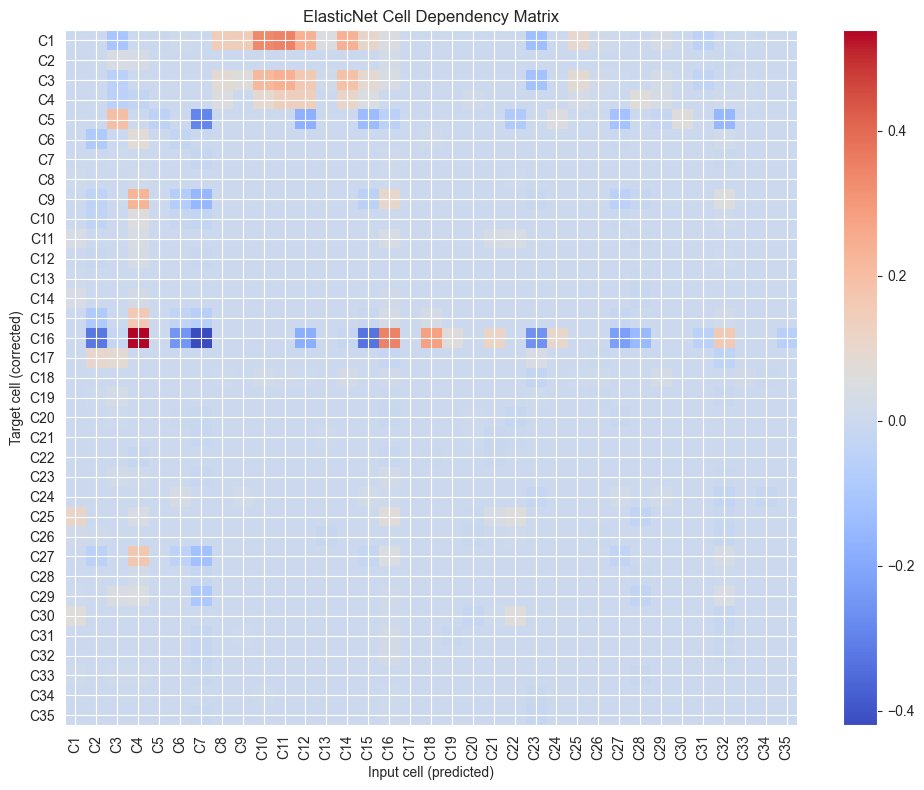

In [77]:
# ============================================================
# HEATMAP OF DEPENDENCIES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(coef_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("ElasticNet Cell Dependency Matrix")

plt.xlabel("Input cell (predicted)")
plt.ylabel("Target cell (corrected)")

plt.xticks(range(35), CELL_COLS, rotation=90)
plt.yticks(range(35), CELL_COLS)

plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# SPARSE SECOND-STAGE REFINER
# Uses only top-k dependency features per target cell
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

SAVE_DIR = r"C:\Users\asola\Downloads"

oof_preds = np.load(os.path.join(SAVE_DIR, "oof_preds.npy"))
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

CELL_COLS = [f"C{i}" for i in range(1, 36)]

def mean_spot_spearman(y_true, y_pred):
    scores = []
    for i in range(len(y_true)):
        corr = spearmanr(y_true[i], y_pred[i]).correlation
        if not np.isnan(corr):
            scores.append(corr)
    return float(np.mean(scores))

In [79]:
# ============================================================
# TRAIN FULL ELASTICNET FIRST TO DISCOVER DEPENDENCIES
# ============================================================

from sklearn.multioutput import MultiOutputRegressor

full_elastic = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(
        ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000)
    )
)

full_elastic.fit(oof_preds, oof_true)

regs = full_elastic.named_steps["multioutputregressor"].estimators_
coef_matrix = np.array([reg.coef_ for reg in regs])  # shape (35, 35)

print("Coef matrix:", coef_matrix.shape)

C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.994e+01, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.187e+01, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

Coef matrix: (35, 35)


In [80]:
# ============================================================
# SPARSE PER-CELL MODEL
# ============================================================

def train_sparse_refiner(oof_preds, oof_true, coef_matrix, top_k=8, model_type="elastic"):
    sparse_models = []
    sparse_features = []
    refined = np.zeros_like(oof_true, dtype=np.float32)

    for target_idx in range(35):
        coefs = coef_matrix[target_idx]

        # choose top-k most influential predicted cells
        top_idx = np.argsort(np.abs(coefs))[::-1][:top_k]
        sparse_features.append(top_idx.tolist())

        X = oof_preds[:, top_idx]
        y = oof_true[:, target_idx]

        if model_type == "ridge":
            model = make_pipeline(
                StandardScaler(),
                Ridge(alpha=1.0)
            )
        else:
            model = make_pipeline(
                StandardScaler(),
                ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000)
            )

        model.fit(X, y)
        pred = model.predict(X)

        refined[:, target_idx] = pred
        sparse_models.append(model)

    refined = np.clip(refined, 0, None)
    score = mean_spot_spearman(oof_true, refined)

    return sparse_models, sparse_features, refined, score

In [81]:
# ============================================================
# TRY DIFFERENT TOP-K VALUES
# ============================================================

sparse_results = []

for top_k in [3, 5, 8, 10, 12, 15, 20, 35]:
    for model_type in ["ridge", "elastic"]:
        models, features, pred, score = train_sparse_refiner(
            oof_preds=oof_preds,
            oof_true=oof_true,
            coef_matrix=coef_matrix,
            top_k=top_k,
            model_type=model_type
        )

        sparse_results.append({
            "top_k": top_k,
            "model_type": model_type,
            "models": models,
            "features": features,
            "pred": pred,
            "score": score
        })

        print(f"top_k={top_k:<3} model={model_type:<7} Spearman={score:.5f}")

best_sparse = max(sparse_results, key=lambda x: x["score"])

print("\nBest sparse refiner:")
print("top_k:", best_sparse["top_k"])
print("model:", best_sparse["model_type"])
print("score:", best_sparse["score"])

top_k=3   model=ridge   Spearman=0.56452
top_k=3   model=elastic Spearman=0.56437
top_k=5   model=ridge   Spearman=0.61872
top_k=5   model=elastic Spearman=0.61795
top_k=8   model=ridge   Spearman=0.62248
top_k=8   model=elastic Spearman=0.62279
top_k=10  model=ridge   Spearman=0.62248
top_k=10  model=elastic Spearman=0.62270
top_k=12  model=ridge   Spearman=0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.172e+01, tolerance: 2.314e+01
  model = cd_fast.enet_coordinate_descent(


top_k=12  model=elastic Spearman=0.62270
top_k=15  model=ridge   Spearman=0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.392e+03, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.709e+02, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

top_k=15  model=elastic Spearman=0.62289
top_k=20  model=ridge   Spearman=0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.041e+03, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.049e+02, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

top_k=20  model=elastic Spearman=0.62286
top_k=35  model=ridge   Spearman=0.62248


C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.773e+02, tolerance: 7.294e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.980e+02, tolerance: 3.528e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\asola\PycharmProjects\PythonProject\MPPrac\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

top_k=35  model=elastic Spearman=0.62286

Best sparse refiner:
top_k: 15
model: elastic
score: 0.6228930618839943


In [84]:
# ============================================================
# COMPARE WITH FULL ELASTICNET
# ============================================================

full_pred = full_elastic.predict(oof_preds)
full_pred = np.clip(full_pred, 0, None)

print("Full ElasticNet:", mean_spot_spearman(oof_true, full_pred))
print("Best Sparse:", best_sparse["score"])

Full ElasticNet: 0.6228608199777697
Best Sparse: 0.6228930618839943


In [86]:
# ============================================================
# SAVE BEST SPARSE REFINER
# ============================================================

SPARSE_DIR = os.path.join(SAVE_DIR, "sparse_refiner")
os.makedirs(SPARSE_DIR, exist_ok=True)

joblib.dump(best_sparse["models"], os.path.join(SPARSE_DIR, "sparse_models.joblib"))

with open(os.path.join(SPARSE_DIR, "sparse_features.json"), "w") as f:
    json.dump(best_sparse["features"], f, indent=4)

summary = {
    "top_k": int(best_sparse["top_k"]),
    "model_type": best_sparse["model_type"],
    "oof_spearman": float(best_sparse["score"])
}

with open(os.path.join(SPARSE_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

np.save(os.path.join(SPARSE_DIR, "sparse_oof_pred.npy"), best_sparse["pred"])

print("Saved sparse refiner to:", SPARSE_DIR)

Saved sparse refiner to: C:\Users\asola\Downloads\sparse_refiner


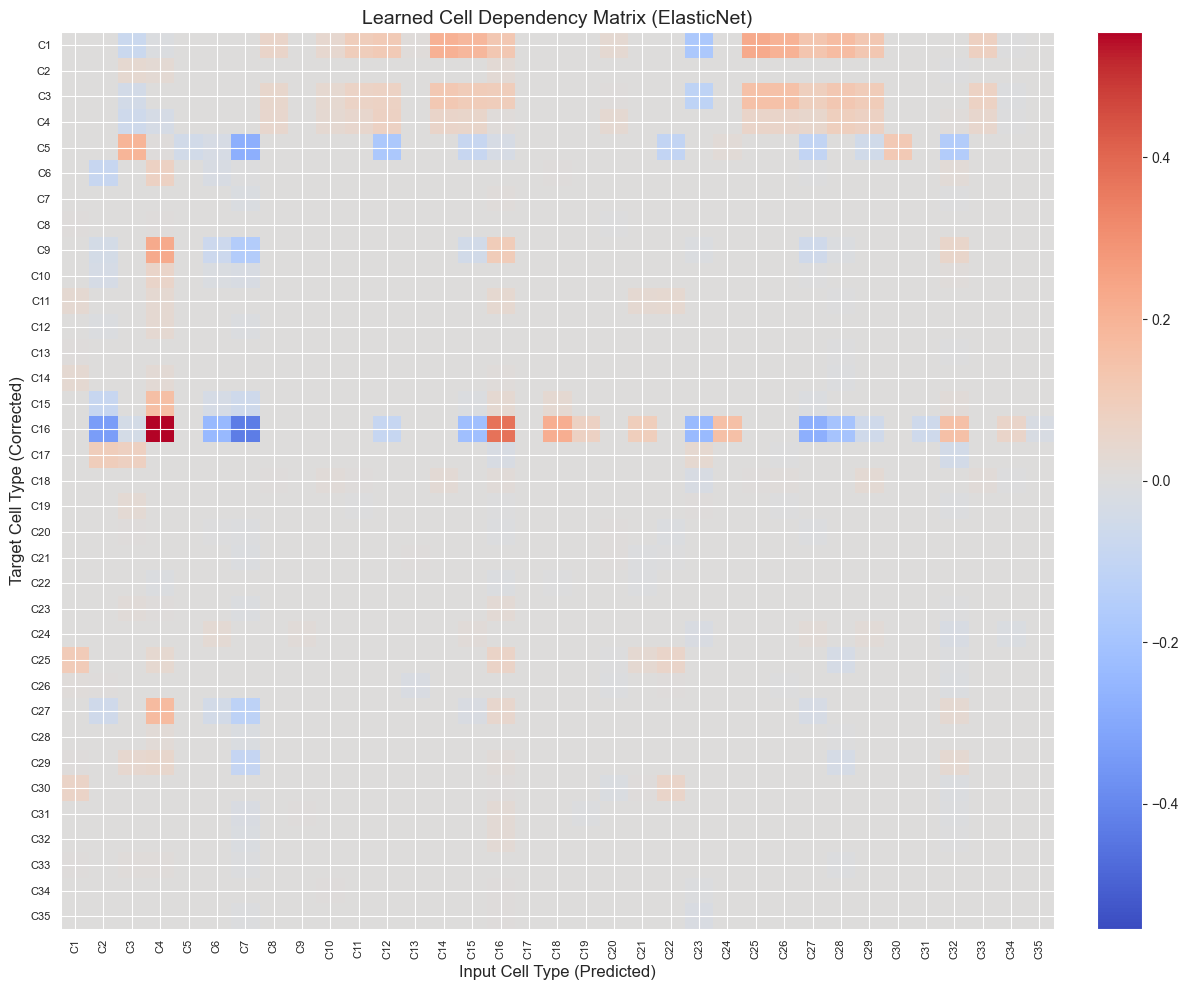

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# coef_matrix should already be (35, 35)
# rows = target cells, columns = input cells

CELL_COLS = [f"C{i}" for i in range(1, 36)]

plt.figure(figsize=(12, 10))

# symmetric color scaling for better interpretation
vmax = np.max(np.abs(coef_matrix))

im = plt.imshow(
    coef_matrix,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax,
    aspect="auto"
)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("Learned Cell Dependency Matrix (ElasticNet)", fontsize=14)

plt.xlabel("Input Cell Type (Predicted)", fontsize=12)
plt.ylabel("Target Cell Type (Corrected)", fontsize=12)

plt.xticks(range(35), CELL_COLS, rotation=90, fontsize=8)
plt.yticks(range(35), CELL_COLS, fontsize=8)

plt.tight_layout()
plt.show()

In [89]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import joblib

SAVE_DIR = r"C:\Users\asola\Downloads"
OUT_DIR = os.path.join(SAVE_DIR, "report_figures")
os.makedirs(OUT_DIR, exist_ok=True)

CELL_COLS = [f"C{i}" for i in range(1, 36)]

# Load OOF data
oof_true = np.load(os.path.join(SAVE_DIR, "oof_true.npy"))

# Choose which prediction to analyze
# Option 1: ElasticNet refined
elastic_pred_path = os.path.join(SAVE_DIR, "oof_preds_refined.npy")

# Option 2: if using final blended prediction
blend_pred_path = os.path.join(SAVE_DIR, "final_oof_pred_blended.npy")

if os.path.exists(blend_pred_path):
    oof_pred = np.load(blend_pred_path)
    model_name = "ElasticNet + Quantile Blend"
else:
    oof_pred = np.load(elastic_pred_path)
    model_name = "ElasticNet Refined"

print("Using:", model_name)
print("True:", oof_true.shape)
print("Pred:", oof_pred.shape)

Using: ElasticNet + Quantile Blend
True: (8349, 35)
Pred: (8349, 35)


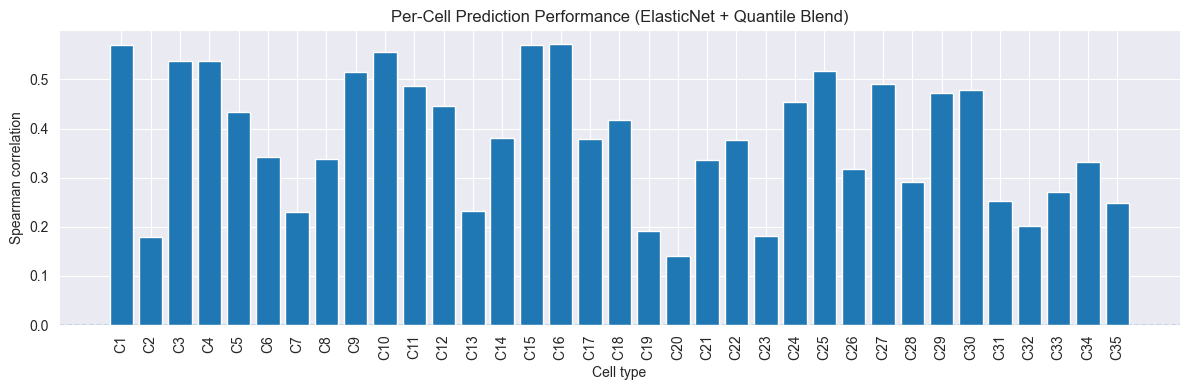

Saved: C:\Users\asola\Downloads\report_figures\per_cell_performance.png


In [90]:
# ============================================================
# PER-CELL SPEARMAN PERFORMANCE
# ============================================================

per_cell_scores = []

for j in range(35):
    corr = spearmanr(oof_true[:, j], oof_pred[:, j]).correlation
    per_cell_scores.append(corr)

per_cell_scores = np.array(per_cell_scores)

plt.figure(figsize=(12, 4))
plt.bar(CELL_COLS, per_cell_scores)
plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Spearman correlation")
plt.xlabel("Cell type")
plt.title(f"Per-Cell Prediction Performance ({model_name})")
plt.tight_layout()

save_path = os.path.join(OUT_DIR, "per_cell_performance.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

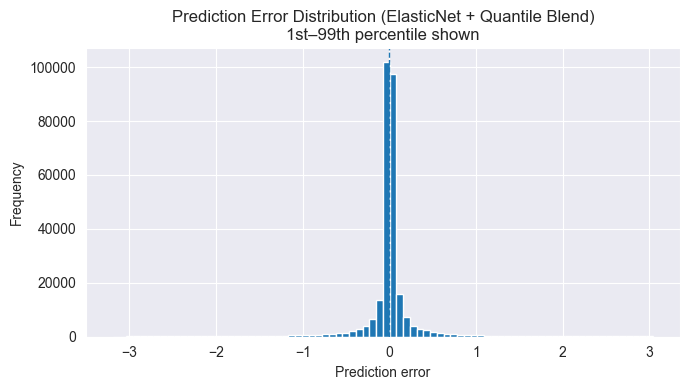

Saved: C:\Users\asola\Downloads\report_figures\error_distribution_clipped.png
Original error min/max: -59.98364 48.98603
Shown range: -3.1943364715576172 3.0454079580306708


In [94]:
# ============================================================
# CLEAN ERROR DISTRIBUTION PLOT
# ============================================================

errors = (oof_pred - oof_true).flatten()

# remove extreme outliers for visualization only
low, high = np.percentile(errors, [1, 99])
errors_clipped = errors[(errors >= low) & (errors <= high)]

plt.figure(figsize=(7, 4))
plt.hist(errors_clipped, bins=80)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Prediction error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution ({model_name})\n1st–99th percentile shown")
plt.tight_layout()

save_path = os.path.join(OUT_DIR, "error_distribution_clipped.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print("Original error min/max:", errors.min(), errors.max())
print("Shown range:", low, high)

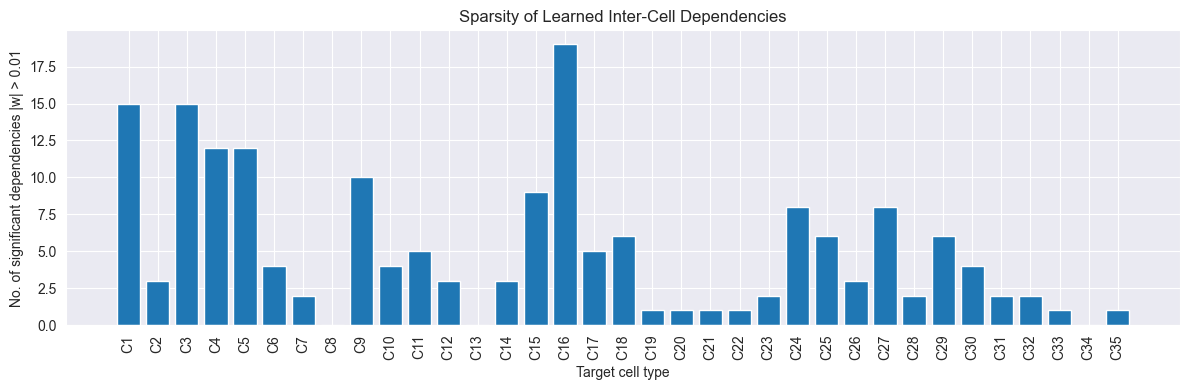

Saved: C:\Users\asola\Downloads\report_figures\dependency_sparsity.png


In [92]:
# ============================================================
# DEPENDENCY SPARSITY ANALYSIS
# ============================================================

# Load ElasticNet model
elastic_model_path = os.path.join(SAVE_DIR, "best_refiner_model.joblib")

if not os.path.exists(elastic_model_path):
    elastic_model_path = os.path.join(SAVE_DIR, "ridge_model.joblib")

model = joblib.load(elastic_model_path)

# Extract coefficient matrix
regressors = model.named_steps["multioutputregressor"].estimators_
coef_matrix = np.array([reg.coef_ for reg in regressors])  # shape: (35, 35)

# Count significant coefficients
threshold = 0.01
nonzero_counts = (np.abs(coef_matrix) > threshold).sum(axis=1)

plt.figure(figsize=(12, 4))
plt.bar(CELL_COLS, nonzero_counts)

plt.xticks(rotation=90)
plt.ylabel(f"No. of significant dependencies |w| > {threshold}")
plt.xlabel("Target cell type")
plt.title("Sparsity of Learned Inter-Cell Dependencies")
plt.tight_layout()

save_path = os.path.join(OUT_DIR, "dependency_sparsity.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [95]:
import os
import shutil
import numpy as np
import joblib
import json

# ================================
# SET PATHS
# ================================
BASE_DIR = r"C:\Users\asola\Downloads"
EXPORT_DIR = os.path.join(BASE_DIR, "project_export")

# your known files
FILES = {
    "oof_true": os.path.join(BASE_DIR, "oof_true.npy"),
    "oof_pred_base": os.path.join(BASE_DIR, "oof_preds_base.npy"),
    "oof_pred_refined": os.path.join(BASE_DIR, "oof_preds_refined.npy"),
    "test_pred": os.path.join(BASE_DIR, "test_predictions.npy"),
    "elastic_model": os.path.join(BASE_DIR, "best_refiner_model.joblib"),
    "ridge_model": os.path.join(BASE_DIR, "ridge_model.joblib"),
}

FIG_DIR = os.path.join(BASE_DIR, "report_figures")

# ================================
# CREATE FOLDERS
# ================================
folders = [
    "models",
    "predictions",
    "figures",
    "configs"
]

for f in folders:
    os.makedirs(os.path.join(EXPORT_DIR, f), exist_ok=True)

print("Folders created")

# ================================
# COPY NUMPY FILES
# ================================
for name, path in FILES.items():
    if os.path.exists(path):
        dest = os.path.join(EXPORT_DIR, "predictions", os.path.basename(path))
        shutil.copy(path, dest)
        print(f"Copied: {name}")
    else:
        print(f"Missing: {name}")

# ================================
# COPY MODELS
# ================================
for key in ["elastic_model", "ridge_model"]:
    path = FILES.get(key)
    if path and os.path.exists(path):
        dest = os.path.join(EXPORT_DIR, "models", os.path.basename(path))
        shutil.copy(path, dest)
        print(f"Copied model: {key}")

# ================================
# COPY FIGURES
# ================================
if os.path.exists(FIG_DIR):
    for file in os.listdir(FIG_DIR):
        src = os.path.join(FIG_DIR, file)
        dst = os.path.join(EXPORT_DIR, "figures", file)
        shutil.copy(src, dst)
    print("Figures copied")
else:
    print("No figure folder found")

# ================================
# SAVE CONFIG / META
# ================================
config = {
    "model_pipeline": "ResNet18 + ElasticNet refinement",
    "metric": "Spearman correlation",
    "cv": "Leave-One-Slide-Out",
    "notes": [
        "Second-stage model uses OOF predictions",
        "ElasticNet used for sparse dependency learning",
        "Coordinate shifting improves convergence but not final score"
    ]
}

with open(os.path.join(EXPORT_DIR, "configs", "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Config saved")

# ================================
# SAVE README
# ================================
readme_text = """
Project: Cell-Type Prediction from H&E Images

Pipeline:
1. Base model: ResNet18 CNN
2. Second stage: ElasticNet refinement using OOF predictions
3. Optional post-processing: Quantile calibration

Contents:
- models/: trained regression models
- predictions/: OOF + test predictions
- figures/: plots used in report
- configs/: metadata and setup info

Notes:
- GCN models were explored but underperformed
- Multi-scale CNN improves base predictions
- Structured refinement improves consistency
"""

with open(os.path.join(EXPORT_DIR, "README.txt"), "w") as f:
    f.write(readme_text)

print("README saved")

print("\n✅ Export complete:", EXPORT_DIR)

Folders created
Copied: oof_true
Missing: oof_pred_base
Copied: oof_pred_refined
Missing: test_pred
Copied: elastic_model
Copied: ridge_model
Copied model: elastic_model
Copied model: ridge_model
Figures copied
Config saved
README saved

✅ Export complete: C:\Users\asola\Downloads\project_export
